# Zebra vs Gabor-patch receptive fields — all three modalities

Two RF estimates per unit, side by side, for every session:

* **Zebra (waven)** — Pearson correlation between the Gabor-wavelet
  decomposition of the pink-noise movie and the unit's response. Signed
  correlation on the full analysis grid (67 x 53). Ranked by `abs_max_value`,
  the peak absolute correlation.
* **Gabor patches** — response to discrete Gabor patches flashed on a coarse grid
  (9 x 9 over ±40°), tested against a shuffle null. Signed z-score per patch
  position. Ranked by `p_value`, taking each unit's best orientation.

For each session two selections are plotted: the top 10 by Zebra correlation,
then the top 10 by Gabor-patch p-value. Units are pooled over all of a session's
groups — probes for ecephys, planes for mesoscope, DMD x channel for SLAP2 —
and each panel is labelled with the group it came from.

**The two maps are not the same grid.** Zebra is fine, the Gabor-patch grid is coarse
patch grid. Both are drawn on visual-degree axes with equal aspect so they can
be compared by position; the Gabor-patch map is blocky by construction.

Nothing here requires a pipeline to have finished. Sessions with results
missing on one side report that and plot an empty panel.

In [59]:
import re
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')
sys.path.append('../scripts')
sys.path.append('../analysis')

from scripts.optimize_waven_parameters import load_rf_results
from scripts.waven_settings import analysis_coverage
from gaussian_envelope import fit_gaussian_envelope, gaussian2d, patch_centres

## Configuration

`RF_ROOT` holds both pipelines' output, one directory per session under each:

```
{RF_ROOT}/gabors/{session}/{GABOR_SIGNAL}/   <- Gabor patches, mesoscope + SLAP2 (dff or events)
{RF_ROOT}/gabors/{session}/                  <- Gabor patches, ecephys (one file per probe, no signal split)
{RF_ROOT}/waven/zebra/optimized/{session}/
```

In [60]:
RF_ROOT = Path('../../../results/allen_open_scope/rf')

# label -> (session, group filter). The filter matches the last '__'-separated
# part of a group key, so SLAP2's 'DMD1__green' / 'DMD2__red' can be split by
# colour channel into their own figures; None keeps every group. The two SLAP2
# channels are different indicators (iGluSnFR4f vs RCaMP3) with different
# kinetics, so pooling them in one ranking would compare unlike things.
SESSIONS = {
    'ecephys 830794':     ('sub-830794_ses-ecephys-830794-2026-01-26-12-02-05_ecephys', None),
    'ecephys 830795':     ('sub-830795_ses-ecephys-830795-2026-02-23-15-03-59_ecephys', None),
    'mesoscope 832700':   ('sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys', None),
    'slap2 829704 green': ('sub-829704_ses-829704-2025-12-18-10-57-36_image+ophys', 'green'),
    'slap2 829704 red':   ('sub-829704_ses-829704-2025-12-18-10-57-36_image+ophys', 'red'),
}


def in_filter(group, keep):
    """True when `group` passes the filter; keep=None accepts everything."""
    return keep is None or group.split('__')[-1] == keep

N_TOP = 10
TRIAL, PHASE = 0, 0        # which waven trial/phase to read where the files carry them

# Which Gabor-patch signal to read for mesoscope / SLAP2 (both now have a
# dff and an events run on disk, under 'gabors/{session}/dff/' and
# '.../events/'). 'events' is OASIS-deconvolved, dff the raw ΔF/F trace —
# same choice `discover_waven`'s `base` argument makes for the Zebra side.
# ecephys has no such split (spikes, not calcium), so it's unaffected.
GABOR_SIGNAL = 'events'

# Zebra maps span the analysis coverage: [azimuth left, right, elevation top, bottom]
xM, xm, yM, ym = analysis_coverage
WAVEN_EXTENT = (xM, xm, ym, yM)

# Figures and the ranked tables behind them are written side by side, one pair
# of files per (session, selection), sharing a stem so a CSV and its figure are
# obviously the same thing. The prefix keeps them apart from the other
# notebooks' output already in plots/.
PLOT_DIR = Path('../plots')
FILE_PREFIX = 'compare_zebra_gabors'


def slug(label):
    """'slap2 829704 green' -> 'slap2-829704-green'."""
    return re.sub(r'[^a-z0-9]+', '-', label.lower()).strip('-')

## Finding the files

The three modalities do not share a filename convention, so the paths are
discovered by globbing rather than formatted from a template:

| | Zebra | Gabor patches |
|---|---|---|
| ecephys   | `optimized__{s}__ProbeA__trial_0__phase_0.h5` | `{s}__rf-spike-count__ProbeA__optimized.h5` (in `gabors/{s}/`) |
| mesoscope | `optimized__{s}__VISp_0__trial_0__phase_0.h5` | `{s}__rf-{{GABOR_SIGNAL}}__VISp_0__optimized.h5` (in `gabors/{s}/{{GABOR_SIGNAL}}/`) |
| SLAP2     | `optimized__{s}__DMD1__green__phase_0.h5`     | `{s}__rf-{{GABOR_SIGNAL}}-green__DMD1__optimized.h5` (in `gabors/{s}/{{GABOR_SIGNAL}}/`) |

`GABOR_SIGNAL` (set below) picks dff or events for the mesoscope/SLAP2 side;
ecephys has no such split — it's spike counts only, one directory per session.

Each is reduced to a **group key** — the probe, the plane, or `DMD__channel` —
so the two sides can be paired. Group keys, not bare unit ids, are what make
the pairing unambiguous: ROI numbering restarts at 0 in every plane and DMD.

In [61]:
def discover_waven(session, base=None):
    """{group_key: path} for one session's waven optimized files.

    `base` defaults to the dff run used throughout this notebook; pass
    `RF_ROOT / 'waven' / 'zebra' / 'optimized' / 'events'` to read the
    events run instead (see the dff-vs-events comparison near the end).
    """
    out = {}
    d = (base if base is not None else RF_ROOT / 'waven' / 'zebra' / 'optimized') / session
    if not d.is_dir():
        return out
    for f in sorted(d.glob(f'optimized__{session}__*.h5')):
        if 'all_values' in f.stem:
            continue
        tail = f.stem[len(f'optimized__{session}__'):]
        # '<group>__trial_<t>__phase_<p>'  or  '<group>__phase_<p>'
        m = re.match(r'^(?P<group>.+?)(?:__trial_(?P<trial>\d+))?__phase_(?P<phase>\d+)$', tail)
        if not m:
            continue
        if int(m.group('phase')) != PHASE:
            continue
        if m.group('trial') is not None and int(m.group('trial')) != TRIAL:
            continue
        out[m.group('group')] = f
    return out


def discover_gabor(session):
    """{group_key: path} for one session's Gabor-patch optimized files, both layouts."""
    out = {}

    # ecephys: 'gabors/{session}/{session}__rf-spike-count__{probe}__optimized.h5'.
    # No dff/events split here (single spike-count signal), so unlike the
    # branch below this reads straight from gabors/{session}/, not a
    # GABOR_SIGNAL subdirectory of it.
    for f in sorted((RF_ROOT / 'gabors' / session).glob(f'{session}__rf-spike-count__*__optimized.h5')):
        out[f.stem.split('__')[-2]] = f

    # mesoscope / SLAP2: 'gabors/{session}/{GABOR_SIGNAL}/{session}__{tag}__{group}__optimized.h5'
    channel_prefix = f'rf-{GABOR_SIGNAL}-'
    for f in sorted((RF_ROOT / 'gabors' / session / GABOR_SIGNAL)
                    .glob(f'{session}__*__optimized.h5')):
        parts = f.stem.split('__')
        if len(parts) < 4:
            continue
        tag, group = parts[-3], parts[-2]
        # 'rf-events-green' (SLAP2) carries the channel; fold it into the key
        # so that it matches the waven side's 'DMD1__green'. Mesoscope's tag
        # is just 'rf-events', no channel, so this leaves `group` untouched.
        if tag.startswith(channel_prefix):
            group = f'{group}__{tag[len(channel_prefix):]}'
        out[group] = f
    return out

In [62]:
print(f'RF_ROOT = {RF_ROOT.resolve()}\n')
print(f'{"session":20s} {"group":16s} {"zebra":>7s} {"Gabor patches":>14s}')
print('-' * 61)
for label, (session, keep) in SESSIONS.items():
    w, s = discover_waven(session), discover_gabor(session)
    groups = sorted(g for g in set(w) | set(s) if in_filter(g, keep))
    if not groups:
        print(f'{label:20s} {"(no files found)":16s} {"-":>7s} {"-":>14s}')
        continue
    for i, g in enumerate(groups):
        print(f'{label if i == 0 else "":20s} {g:16s} '
              f'{"yes" if g in w else "-":>7s} {"yes" if g in s else "-":>14s}')

RF_ROOT = /home/marcelraabe/projects/SPP2205_local/results/allen_open_scope/rf

session              group              zebra  Gabor patches
-------------------------------------------------------------
ecephys 830794       ProbeA               yes            yes
                     ProbeB               yes            yes
                     ProbeC               yes            yes
                     ProbeD               yes            yes
                     ProbeE               yes            yes
                     ProbeF               yes            yes
ecephys 830795       ProbeA               yes              -
                     ProbeB               yes              -
                     ProbeC               yes              -
                     ProbeD               yes              -
                     ProbeE               yes              -
                     ProbeF               yes              -
mesoscope 832700     VISl_4               yes            yes
    

## Loading

Both loaders return one row per unit with an `rf_map` column, so a single plot
function serves both. Unit ids are canonicalised before the join: ecephys uses
UUIDs on both sides, but the mesoscope's waven files name units by bare row
index (`'0'`) while its Gabor-patch files use `'VISp_0_roi0'`. Stripping a trailing
`_roi<n>` reduces both to the same key. That key is only unique *within* a
group, which is why the merge happens per group and `group` is carried along.

In [63]:
# theta_rad, not theta_deg: theta_deg is Waven's own degree convention and does
# not equal rad2deg(theta_rad) — for n_thetas=10 it steps in 22.5° up to 180°,
# while the actual filter bank steps in 18° up to 162°. theta_rad is the value
# looked up straight out of the library attrs, so it is the one to display.
WAVEN_COLS = ['unit_id', 'abs_max_value', 'rf_map', 'delay', 'duration',
              'x_deg', 'y_deg', 'theta_rad', 'theta_deg', 'sigma_deg', 'frequency']
GABOR_COLS = ['unit_id', 'p_value', 'z_max', 'ori_idx', 'ori_rad', 'delay',
               'duration', 'rf_map', 'rf_maps_all', 'p_all']


def canonical_unit_id(uid):
    """'VISp_0_roi12' -> '12';  'DMD1_green_roi3' -> '3';  a UUID -> unchanged."""
    m = re.match(r'^.*_roi(\d+)$', str(uid))
    return m.group(1) if m else str(uid)


def load_waven(path):
    """One row per unit: unit_id, abs_max_value, rf_map (nx, ny), best delay/duration."""
    if path is None or not Path(path).exists():
        return pd.DataFrame(columns=WAVEN_COLS)
    df = load_rf_results(path)
    if 'rf_map' not in df.columns:
        print(f'  {Path(path).name}: no rf_maps stored (load_rf_maps was not run) — skipping')
        return pd.DataFrame(columns=WAVEN_COLS)
    df = df[[c for c in WAVEN_COLS if c in df.columns]].copy()
    df['unit_id'] = df['unit_id'].map(canonical_unit_id)
    return df


def load_gabor(path):
    """One row per unit, reduced to the unit's best orientation.

    p_value and z_score_response are stored per (unit, orientation); the best
    orientation is the one with the lowest p-value, and its z-score map is what
    gets plotted. Orientations frequently tie, because a permutation test cannot
    resolve below 1/(n_shuffle+1) and many units sit on that floor in more than
    one orientation. A plain argmin would then pick whichever orientation comes
    first, which is arbitrary; among the tied ones the largest peak |z| wins.
    """
    if path is None or not Path(path).exists():
        empty = pd.DataFrame(columns=GABOR_COLS)
        empty.attrs['extent'] = (-45, 45, -45, 45)
        return empty

    with h5py.File(path, 'r') as hf:
        unit_names = hf['unit_names'][:].astype(str)
        p_values = hf['p_value'][:]                 # (n_units, n_orientations)
        z_scores = hf['z_score_response'][:]        # (n_units, n_orientations, nx, ny)
        orientations = hf['orientations'][:]
        x_pos, y_pos = hf['x_positions'][:], hf['y_positions'][:]
        best_delay = hf['best_delay'][:] if 'best_delay' in hf else None
        best_duration = hf['best_duration'][:] if 'best_duration' in hf else None
        n_shuffle = int(hf.attrs.get('n_shuffle', 0))

    # peak |z| of every orientation's map, used to break ties on p
    z_peak = np.nanmax(np.abs(z_scores), axis=(2, 3))       # (n_units, n_orientations)
    at_min = p_values <= p_values.min(axis=1, keepdims=True) + 1e-12
    best_ori = np.argmax(np.where(at_min, z_peak, -np.inf), axis=1)
    u = np.arange(len(unit_names))

    df = pd.DataFrame({
        'unit_id': [canonical_unit_id(x) for x in unit_names],
        'p_value': p_values[u, best_ori],
        'ori_idx': best_ori,
        'ori_rad': orientations[best_ori],
        'delay': best_delay[u, best_ori] if best_delay is not None else np.nan,
        'duration': best_duration[u, best_ori] if best_duration is not None else np.nan,
    })
    df['rf_map'] = [z_scores[i, best_ori[i]] for i in u]
    # every orientation, for the side-by-side columns; the best one is still
    # what p_value/z_max/ranking refer to
    df['rf_maps_all'] = [z_scores[i] for i in u]      # (n_orientations, nx, ny)
    df['p_all'] = [p_values[i] for i in u]            # (n_orientations,)
    # peak |z| of the chosen map: the continuous measure of how strong the
    # response is, needed because p saturates at its floor (see Selection B)
    df['z_max'] = z_peak[u, best_ori]
    df.attrs['extent'] = _extent_from_centres(x_pos, y_pos)
    df.attrs['n_shuffle'] = n_shuffle
    # a tuple, not an array: pandas compares .attrs for equality inside concat
    # (nlargest goes through it) and an array makes that comparison ambiguous
    df.attrs['orientations'] = tuple(float(o) for o in orientations)
    return df


def _extent_from_centres(x_pos, y_pos):
    """imshow extent covering pixel edges, given the pixel centres."""
    dx = np.median(np.diff(x_pos)) if len(x_pos) > 1 else 1.0
    dy = np.median(np.diff(y_pos)) if len(y_pos) > 1 else 1.0
    return (x_pos[0] - dx / 2, x_pos[-1] + dx / 2,
            y_pos[0] - dy / 2, y_pos[-1] + dy / 2)

In [64]:
def load_session(session, keep=None):
    """Units of one session, pooled over the groups that pass `keep`.

    Returns (df, info). df carries a `group` column and one row per paired unit;
    info records the per-group counts so a partial session is visible rather
    than silently short.
    """
    waven_files, gabor_files = discover_waven(session), discover_gabor(session)
    frames, info, extent, n_shuffle = [], [], None, 0
    orientations = ()

    for group in sorted(g for g in set(waven_files) | set(gabor_files)
                        if in_filter(g, keep)):
        w = load_waven(waven_files.get(group))
        s = load_gabor(gabor_files.get(group))
        if extent is None and len(s):
            extent, n_shuffle = s.attrs['extent'], s.attrs.get('n_shuffle', 0)
            orientations = s.attrs.get('orientations', ())

        # outer, not inner: a session with only one pipeline finished still
        # contributes its units, and the missing side is drawn as a blank panel
        merged = w.merge(s, on='unit_id', how='outer', suffixes=('_zebra', '_gabor'))
        merged.insert(0, 'group', group)
        n_paired = int(merged['abs_max_value'].notna().sum() and
                       merged[['abs_max_value', 'p_value']].notna().all(axis=1).sum())
        info.append({'group': group, 'zebra': len(w), 'gabor patches': len(s),
                     'rows': len(merged), 'paired': n_paired})
        if len(merged):
            frames.append(merged)

    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(
        columns=['group', 'unit_id', 'abs_max_value', 'rf_map_zebra', 'p_value', 'rf_map_gabor'])
    df.attrs['extent'] = extent or (-45, 45, -45, 45)
    df.attrs['n_shuffle'] = n_shuffle
    # a tuple, not an array: pandas compares .attrs for equality inside concat
    # (nlargest goes through it) and an array makes that comparison ambiguous
    df.attrs['orientations'] = tuple(float(o) for o in orientations)
    return df, pd.DataFrame(info)

In [65]:
paired = {}
for label, (session, keep) in SESSIONS.items():
    print(f'\n=== {label} ===')
    df, info = load_session(session, keep)
    paired[label] = df
    if info.empty:
        print('  no result files at all')
    else:
        print(info.to_string(index=False))
    n_both = int(df[['abs_max_value', 'p_value']].notna().all(axis=1).sum()) if len(df) else 0
    print(f'  -> {len(df)} units total, {n_both} with both pipelines'
          + (f', n_shuffle={df.attrs["n_shuffle"]}' if len(df) else ''))


=== ecephys 830794 ===


 group  zebra  gabor patches  rows  paired
ProbeA    662            662   662     662
ProbeB    553            553   553     553
ProbeC    673            673   673     673
ProbeD    645            645   645     645
ProbeE    693            693   693     693
ProbeF    762            762   762     762
  -> 3988 units total, 3988 with both pipelines, n_shuffle=0

=== ecephys 830795 ===
 group  zebra  gabor patches  rows  paired
ProbeA    678              0   678       0
ProbeB    460              0   460       0
ProbeC    641              0   641       0
ProbeD    583              0   583       0
ProbeE    535              0   535       0
ProbeF    543              0   543       0
  -> 3440 units total, 0 with both pipelines, n_shuffle=0

=== mesoscope 832700 ===
 group  zebra  gabor patches  rows  paired
VISl_4    349            349   349     349
VISl_5    385            385   385     385
VISl_6    126            126   126     126
VISl_7    314            314   314     314
VISp_0    413 

## Unit locations (CCF structure acronym), ecephys only

Row labels in the comparison plots below also show each unit's anatomical
location. That isn't stored in any of the HDF5 result files this notebook
otherwise reads — waven and the Gabor-patch pipeline both key on unit id and
never carried the electrode's CCF structure along — so it's fetched once
here, straight from the local NWB file's units table (`units_df()`'s
`location` column, e.g. `'VISp5'`), and cached to disk the same way the
Gaussian fits later on are: skip the fetch if it's already on disk, otherwise
fetch and save.

Only ecephys goes through this. `units_df()`'s `location` column comes off
the electrodes table, which only exists for that modality — mesoscope's
imaged area is already in its group name (`'VISp_0'`) and is read off
directly in `plot_rf_pairs` with no lookup needed; SLAP2's `DMD1`/`DMD2`
groups don't correspond to a distinct area, so no location is shown there.


In [66]:
LOCATIONS_PATH = PLOT_DIR / f'{FILE_PREFIX}__unit_locations.csv'
RAWDATA_ROOT = Path('../../../rawdata/allen_open_scope')


def compute_unit_locations(sessions):
    """(label, group, unit_id) -> CCF structure acronym, ecephys sessions only.

    Opens the local NWB file directly via units_df() -- unlike everything
    else in this notebook, which only ever reads the small precomputed HDF5
    result files. That real file I/O is slow enough to cache rather than
    redo on every rerun.
    """
    import utils

    rows = []
    for label, (session, keep) in sessions.items():
        if 'ecephys' not in session:
            continue
        matches = list(RAWDATA_ROOT.glob(f'**/{session}.nwb'))
        if not matches:
            print(f'  {label}: no local NWB file found under {RAWDATA_ROOT} - skipping')
            continue
        with utils.open_local(matches[0]) as stream:
            units = stream.units_df()
        if 'location' not in units.columns:
            print(f'  {label}: units table has no location column - skipping')
            continue
        for _, r in units[['unit_name', 'probe', 'location']].iterrows():
            # unit_name comes back as raw bytes from the bulk h5py read in
            # units_df(); str() on bytes gives "b'...'", not the UUID itself
            uid = r['unit_name'].decode() if isinstance(r['unit_name'], bytes) else str(r['unit_name'])
            rows.append({'label': label, 'group': r['probe'],
                        'unit_id': uid, 'location': r['location']})
    # explicit columns for the same reason as the Gaussian fits below: an
    # empty `rows` must still produce a file pd.read_csv can parse back.
    return pd.DataFrame(rows, columns=['label', 'group', 'unit_id', 'location'])


if LOCATIONS_PATH.exists():
    print(f'  {LOCATIONS_PATH.name} already on disk - skipping the fetch. '
          'Delete it to force a redo (e.g. after downloading a new ecephys session).')
else:
    locations = compute_unit_locations(SESSIONS)
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    locations.to_csv(LOCATIONS_PATH, index=False)
    print(f'  -> {LOCATIONS_PATH.name}  ({len(locations)} units)')


  compare_zebra_gabors__unit_locations.csv already on disk - skipping the fetch. Delete it to force a redo (e.g. after downloading a new ecephys session).


In [67]:
locations_loaded = pd.read_csv(LOCATIONS_PATH, dtype={'unit_id': str})
location_by_unit = {(r.label, r.group, r.unit_id): r.location
                    for r in locations_loaded.itertuples(index=False)}
print(f'loaded {len(location_by_unit)} unit locations from {LOCATIONS_PATH.name}')


loaded 7406 unit locations from compare_zebra_gabors__unit_locations.csv


## Plotting

Both maps are signed with a meaningful zero, so both get a diverging colormap
on limits symmetric about zero — otherwise the midpoint colour drifts off zero
and a weakly negative region reads as blank. Each panel is scaled to its own
peak: the two pipelines produce different units (correlation vs z-score) and a
shared scale would only make the weaker one unreadable.

Following the project convention in `analysis/plotting.py`: `coolwarm`, limits
`±|max|`, and the map transposed so that x is azimuth and y elevation.

The two maps do not agree on which end of their second axis is up, so they need
different `origin`. The zebra map inherits the row order of the stimulus movie
— `cv2` reads frame row 0 as the top of the screen, and waven keeps that through
the filter library and the correlation — so its index 0 is elevation **+47.5°**
and it is drawn with `origin='upper'`. The Gabor-patch map is accumulated over
ascending `y_positions`, so its index 0 is **−40°** and it keeps `origin='lower'`.
Drawing both the same way mirrored the zebra panel about elevation 0.

In [68]:
# whole RF maps: fine in memory, meaningless in a CSV cell
MAP_COLS = ['rf_map_zebra', 'rf_map_gabor', 'rf_maps_all', 'p_all']
# the columns report() prints, first; the rest of the row follows
TABLE_LEAD = ['group', 'unit_id', 'abs_max_value', 'p_value', 'z_max']


def save_table(top, stem):
    """Write one ranked selection to CSV, without the array-valued map columns.

    The rank is written out as its own column: row order is the entire content
    of these tables and is the first thing lost when a CSV is re-read or sorted.
    """
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    path = PLOT_DIR / f'{FILE_PREFIX}__{stem}.csv'
    out = top.drop(columns=[c for c in MAP_COLS if c in top.columns]).copy()
    out.insert(0, 'rank', np.arange(1, len(out) + 1))
    lead = ['rank'] + [c for c in TABLE_LEAD if c in out.columns]
    out = out[lead + [c for c in out.columns if c not in lead]]
    out.to_csv(path, index=False)
    print(f'  -> {path.name}  ({len(out)} rows)')
    return path


def save_figure(fig, stem):
    """Write one figure beside the CSV it was drawn from."""
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    path = PLOT_DIR / f'{FILE_PREFIX}__{stem}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'  -> {path.name}')
    return path


def plot_rf_pairs(df, title, gabor_extent, orientations, label, fits_by_unit, location_by_unit):
    """One row per unit: the Zebra map, then the Gabor-patch map at every orientation.

    The Zebra panel is titled with the orientation of its best-fitting Gabor
    (from theta_rad). The Gabor-patch panels share one colour scale within a row, so
    the three orientations are comparable to each other; the Zebra panel keeps
    its own, since correlation and z-score are different units.
    """
    n_ori = len(orientations)
    n = len(df)
    if n == 0:
        fig, ax = plt.subplots(figsize=(6.4, 1.5))
        ax.text(.5, .5, f'{title}\nno paired units available yet',
                ha='center', va='center', fontsize=11, color='.35')
        ax.set_axis_off()
        return fig

    ncols = 1 + n_ori
    fig_h = 2.0 * n
    fig, axs = plt.subplots(n, ncols, figsize=(2.55 * ncols, fig_h), squeeze=False)

    def blank(ax, msg):
        """Keep the axes (so the row label survives) but draw nothing."""
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        ax.text(.5, .5, msg, transform=ax.transAxes, ha='center', va='center',
                fontsize=8, color='.55')

    def show(ax, m, extent, vmax, origin='lower'):
        # aspect='equal' so that a degree is the same distance in every column:
        # the grids differ (120x95 vs 90x90 deg) and stretching each to fill its
        # box would make positions incomparable, which is what these rows exist
        # to show.
        #
        # `origin` is not cosmetic: the two pipelines store elevation in opposite
        # directions and the caller has to say which. The zebra map inherits the
        # movie's row order, so its axis 1 runs top -> bottom and index 0 is
        # +47.5 deg (cv2 reads frame row 0 as the top of the screen, and waven's
        # own y_deg conversion, |yi - ny| * dy/ny + ym, agrees). The Gabor-patch
        # map is filled as R[trial, x_i, y_i] over ascending y_positions, so its
        # axis 1 runs bottom -> top. Drawing both with origin='lower' mirrored
        # the zebra panel about elevation 0.
        im = ax.imshow(m.T, cmap='coolwarm', vmin=-vmax, vmax=vmax,
                       extent=extent, origin=origin, aspect='equal',
                       interpolation='nearest')
        ax.axhline(0, color='.4', lw=.4)
        ax.axvline(0, color='.4', lw=.4)
        ax.tick_params(labelsize=6)
        fig.colorbar(im, ax=ax, fraction=.046, pad=.02).ax.tick_params(labelsize=5)

    for i, (_, row) in enumerate(df.iterrows()):
        # --- Zebra, with the orientation of the best-fitting filter ----------
        m = row['rf_map_zebra']
        if isinstance(m, np.ndarray):
            v = np.nanmax(np.abs(m))
            show(axs[i, 0], m, WAVEN_EXTENT, v if np.isfinite(v) and v > 0 else 1.0,
                 origin='upper')      # row 0 of the zebra map is the top of the screen
            # the Gabor-patch grid's own extent (+-40 deg), so it's visible on
            # the wider Zebra panel which side of it a unit's peak falls on
            for edge in (-40, 40):
                axs[i, 0].axvline(edge, color='.75', lw=.6, zorder=1)
                axs[i, 0].axhline(edge, color='.75', lw=.6, zorder=1)
            theta = np.rad2deg(row['theta_rad']) % 180
            axs[i, 0].set_title(f'|r|max = {row["abs_max_value"]:.3f}\n'
                                f'best filter θ = {theta:.0f}°', fontsize=8)
            # x_deg/y_deg is the position of abs_max_value itself (waven picks
            # rf_map as the correlation slice at that same best x,y,θ,σ,f), so
            # marking it directly avoids re-deriving an argmax over the map.
            axs[i, 0].plot(row['x_deg'], row['y_deg'], marker='x', color='k',
                           markersize=8, markeredgewidth=2, zorder=5)
        else:
            blank(axs[i, 0], 'no Zebra\nresult yet')

        uid = str(row['unit_id'])
        # ecephys: looked up from the cached NWB units table. mesoscope:
        # read straight off the group name ('VISp_0' -> 'VISp'), no lookup
        # needed. SLAP2: no per-group area, so no location line at all.
        loc = location_by_unit.get((label, row['group'], uid))
        if loc is None and label.startswith('mesoscope'):
            loc = row['group'].split('_')[0]
        label_lines = ([loc] if loc else []) + [row['group'], uid[:8]]
        axs[i, 0].set_ylabel('\n'.join(label_lines), fontsize=7,
                             rotation=0, ha='right', va='center', labelpad=26)

        # --- Gabor patches, one panel per orientation, shared scale within the row --
        maps = row['rf_maps_all']
        if not isinstance(maps, np.ndarray):
            for j in range(n_ori):
                blank(axs[i, 1 + j], 'no Gabor-patch\nresult yet')
            continue
        v_all = np.nanmax(np.abs(maps))
        v_all = v_all if np.isfinite(v_all) and v_all > 0 else 1.0
        best_j = int(row['ori_idx']) if pd.notna(row['ori_idx']) else -1
        _, gnx, gny = maps.shape
        gx_pos = patch_centres(gabor_extent[:2], gnx)
        gy_pos = patch_centres(gabor_extent[2:], gny)
        for j in range(n_ori):
            ax = axs[i, 1 + j]
            show(ax, maps[j], gabor_extent, v_all)
            is_best = (j == best_j)
            ax.set_title(f'θ = {np.rad2deg(orientations[j]):.0f}°\n'
                         f'p = {row["p_all"][j]:.4f}', fontsize=8,
                         weight='bold' if is_best else 'normal')
            if is_best:
                # the orientation p_value and the ranking refer to
                for sp in ax.spines.values():
                    sp.set_edgecolor('#b2182b')
                    sp.set_linewidth(1.8)

                # Gaussian envelope for this, the unit's most significant
                # orientation map. Fitting ~10k units per session inline here
                # would be slow to replot, so it isn't done in this function
                # at all — `fits_by_unit` is the precomputed table written and
                # read back by the 'Gaussian envelope fits' section above,
                # keyed the same way the units in `df` are: (label, group,
                # unit_id). A unit missing from it either scored p > the fit
                # threshold there, or (rarely) the fit didn't converge —
                # either way there is nothing to draw.
                fit = fits_by_unit.get((label, row['group'], str(row['unit_id'])))
                if fit is not None and bool(fit['success']) and fit['r2'] >= fit['min_r2']:
                    fx = np.linspace(gx_pos.min(), gx_pos.max(), 100)
                    fy = np.linspace(gy_pos.min(), gy_pos.max(), 100)
                    FX, FY = np.meshgrid(fx, fy, indexing='ij')
                    model = gaussian2d((FX.ravel(), FY.ravel()), fit['amp'], fit['x0'],
                                       fit['y0'], fit['sigma_x'], fit['sigma_y'],
                                       fit['theta'], 0.0).reshape(FX.shape)
                    # 1 and 2 sigma of the fitted envelope, as fractions of its own peak
                    ax.contour(FX, FY, model / fit['amp'], levels=[np.exp(-2), np.exp(-.5)],
                               colors='k', linewidths=[.7, 1.2])
                    ax.plot(fit['x0'], fit['y0'], marker='x', color='k', ms=6, mew=1.2)

    for ax in axs[-1]:
        ax.set_xlabel('Azimuth (deg)', fontsize=8)

    # Leave room for the suptitle and the two group headers, in inches rather
    # than as a figure fraction — a fraction would scale with n and swallow the
    # whole first row on a tall figure.
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.85 / fig_h))

    # Place the headers from the laid-out axes positions, so they clear the
    # first row's per-panel titles whatever the row count.
    top = max(axs[0, c].get_position().y1 for c in range(ncols))
    y_hdr = min(top + 0.42 / fig_h, 1 - 0.30 / fig_h)
    b0 = axs[0, 0].get_position()
    fig.text(b0.x0 + b0.width / 2, y_hdr, 'Zebra',
             ha='center', va='bottom', fontsize=11, weight='bold')
    # a session whose Gabor-patch run has not happened yet has no orientation
    # columns at all, so there is no second header to place
    if n_ori:
        bl, br = axs[0, 1].get_position(), axs[0, ncols - 1].get_position()
        fig.text((bl.x0 + br.x1) / 2, y_hdr,
                 'Gabor patches',
                 ha='center', va='bottom', fontsize=11, weight='bold')

    fig.suptitle(title, fontsize=11, y=1 - 0.06 / fig_h)
    return fig


def report(df, label, by, ascending):
    """Print the ranked table that a figure is about.

    `by` may name several columns with matching `ascending` flags. Selection B
    needs that: a shuffle test cannot report a p-value below 1/(n_shuffle+1),
    and with thousands of units hundreds land exactly on that floor. Ranking on
    p alone would then return whichever rows happen to come first — in practice
    the lowest unit ids of the first group, which is an alphabetical slice
    masquerading as a significance ranking. Peak |z| breaks the tie with the
    strength of the response itself.

    Units missing the ranking key are dropped rather than ranked: with the outer
    join a unit can be present from one pipeline only, and a NaN key is not a
    poor score. The other pipeline's columns print as '-' for those rows.
    """
    ranked = df.dropna(subset=list(by)) if len(df) else df
    if not len(ranked):
        print(f'{label}: nothing to rank '
              f'({len(df)} units, none carrying {" + ".join(by)})')
        return ranked
    top = ranked.sort_values(by, ascending=ascending).head(N_TOP)

    def fmt(v, width, prec):
        return f'{v:{width}.{prec}f}' if pd.notna(v) else f'{"-":>{width}}'

    print(f'{label}')
    print(f'  {"group":12s} {"unit":>10s}  {"|r|max":>7s}  {"Gabor p":>9s}  {"|z|max":>7s}')
    for _, r in top.iterrows():
        print(f'  {r.group:12s} {str(r.unit_id)[:10]:>10s}  '
              f'{fmt(r.abs_max_value, 7, 3)}  {fmt(r.p_value, 9, 4)}  {fmt(r.z_max, 7, 2)}')
    return top

## Gaussian envelope fits for the Gabor-patch overlay

The best-orientation panel highlighted in every row of Selections A and B
below gets a fitted Gaussian envelope contour. Fitting is a per-unit
`curve_fit`, and thousands of units across five sessions is too slow to redo
on every replot, so it happens once, here, ahead of the plotting section.

Only units worth fitting are fit: `p_value <= FIT_P_THRESH`, and — when
several orientations of the same unit are tied at that unit's minimum p —
only the one `load_gabor` already picked as *the* best, by the highest
z-response among the tied orientations. That is the same single map each
plot panel below highlights in red, so the fit always matches what's drawn.

The result is written to disk, and the plotting cells never call
`fit_gaussian_envelope` themselves — they only read the file back in the
next cell. That keeps the fit and the plot reproducible independently of
each other: replotting doesn't refit, and refitting doesn't require
replotting.

The compute cell below also skips itself if `FITS_PATH` already exists, so
rerunning the notebook doesn't redo the ~2 minute fit every time. `FITS_PATH`
is named after both `FIT_P_THRESH` and `GABOR_SIGNAL` — the mesoscope/SLAP2
maps being fit are different arrays depending on which signal is selected, so
a dff-run cache and an events-run cache have to be kept apart rather than one
silently masking the other. Delete the CSV (or change either setting, which
changes `FITS_PATH`'s name) to force a recompute after the underlying
Gabor-patch results change.


In [69]:
FIT_P_THRESH = 0.01
FIT_COLS = ['success', 'r2', 'min_r2', 'sigma', 'sigma_x', 'sigma_y', 'x0', 'y0',
            'theta', 'amp', 'railed', 'edge', 'sigma_resolution']
FIT_ID_COLS = ['label', 'group', 'unit_id', 'p_value', 'z_max']
FITS_PATH = PLOT_DIR / f'{FILE_PREFIX}__gaussian_fits__{GABOR_SIGNAL}__p{FIT_P_THRESH}.csv'


def compute_gaussian_fits(paired, p_thresh=FIT_P_THRESH):
    """Fit every unit's best-orientation Gabor-patch map, for p_value <= p_thresh.

    One row per (label, group, unit_id) — the same keys `plot_rf_pairs` looks
    fits up by — carrying every field `fit_gaussian_envelope` returns, so a
    fit's quality (`r2`, `railed`, ...) survives the round trip to disk.
    """
    rows = []
    for label, df in paired.items():
        sub = df[(df['p_value'] <= p_thresh)
                 & df['rf_map_gabor'].map(lambda m: isinstance(m, np.ndarray))]
        if not len(sub):
            continue
        extent = df.attrs['extent']
        nx, ny = sub['rf_map_gabor'].iloc[0].shape
        gx = patch_centres(extent[:2], nx)
        gy = patch_centres(extent[2:], ny)
        for _, r in sub.iterrows():
            fit = fit_gaussian_envelope(r['rf_map_gabor'], gx, gy)
            row = {'label': label, 'group': r['group'], 'unit_id': str(r['unit_id']),
                   'p_value': r['p_value'], 'z_max': r['z_max']}
            row.update({c: fit[c] for c in FIT_COLS})
            rows.append(row)
    # explicit columns, not just pd.DataFrame(rows): an all-empty `rows` (no
    # session in `paired` had a unit at p <= p_thresh — this genuinely
    # happens, e.g. a session with zero Gabor-patch results) would otherwise
    # come back with *zero columns*, and to_csv on that writes a headerless
    # file that pd.read_csv can't parse back at all.
    return pd.DataFrame(rows, columns=FIT_ID_COLS + FIT_COLS)


if FITS_PATH.exists():
    print(f'  {FITS_PATH.name} already on disk — skipping the refit. '
          'Delete it (or change FITS_PATH / FIT_P_THRESH) to force a recompute.')
else:
    fits = compute_gaussian_fits(paired)
    if not len(fits):
        print(f'  no units at p <= {FIT_P_THRESH} across {len(paired)} session(s) in `paired` — '
              'rerun the "paired = {...}" cell above if that looks short, then rerun this cell.')
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    fits.to_csv(FITS_PATH, index=False)
    n_usable = int((fits['success'] & (fits['r2'] >= fits['min_r2'])).sum()) if len(fits) else 0
    print(f'  -> {FITS_PATH.name}  ({len(fits)} units fit, p <= {FIT_P_THRESH}; '
          f'{n_usable} converged with r2 >= min_r2)')


  compare_zebra_gabors__gaussian_fits__events__p0.01.csv already on disk — skipping the refit. Delete it (or change FITS_PATH / FIT_P_THRESH) to force a recompute.


In [70]:
# Plotting reads back from disk rather than reusing `fits` in memory, so the
# figures below reflect exactly what's saved — the same guarantee `save_table`
# / `save_figure` give the CSVs and PNGs elsewhere in this notebook.
fits_loaded = pd.read_csv(FITS_PATH)
fits_by_unit = {(r.label, r.group, str(r.unit_id)): r._asdict()
               for r in fits_loaded.itertuples(index=False)}
print(f'loaded {len(fits_by_unit)} fits from {FITS_PATH.name}')


loaded 3747 fits from compare_zebra_gabors__gaussian_fits__events__p0.01.csv


## One unit, side by side

A single unit's two maps, for looking at one case closely rather than at a
ranked selection: the Zebra correlation map on the left, the Gabor-patch
z-score map at that unit's best orientation on the right. Same conventions as
the selections below -- `coolwarm` on limits symmetric about zero, per-panel
scaling, equal aspect on visual-degree axes, and the opposite `origin` for the
two pipelines.

The unit is named by its rank in the Zebra ranking rather than by id, so the
cell keeps pointing at the same *case* -- here the third-strongest correlation
in ecephys 830794 -- if the pipeline is rerun and the ids change.


rank 3 by Zebra correlation in ecephys 830794: ProbeD / f4e75445-767a-429e-ae19-c7d993efd1b4  (|r|max = 0.587)
  -> compare_zebra_gabors__ecephys-830794__zebra_rank3.png


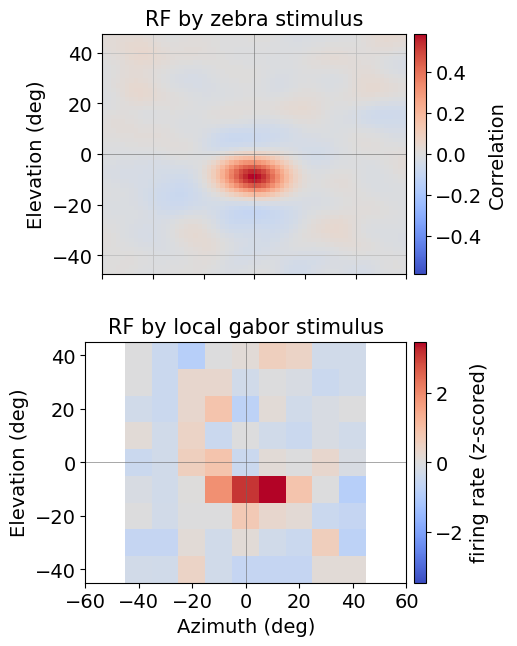

In [73]:
UNIT_LABEL = 'ecephys 830794'   # which session in `paired`
UNIT_RANK = 3                   # 1-based rank by abs_max_value, as in Selection A
UNIT_GROUP = None               # e.g. 'ProbeD' to rank within one probe only

# One knob for every piece of text in the figure. Axis labels, tick labels
# (both the panels' and the colorbars') and the panel titles all scale from
# it, so the figure stays legible when it is dropped into a slide or a
# figure panel at a different size.
FONTSIZE = 14
TITLE_FONTSIZE = FONTSIZE + 1


def unit_by_zebra_rank(paired, label, rank, group=None):
    """The `rank`-th unit of one session by peak Zebra correlation.

    Ranks exactly as Selection A does -- `abs_max_value` descending, pooled
    over the session's groups unless `group` narrows it -- so "rank 3 here" and
    "the third row of that figure" are the same unit.
    """
    df = paired[label]
    sel = df[df['group'] == group] if group is not None else df
    sel = sel.dropna(subset=['abs_max_value']).sort_values('abs_max_value', ascending=False)
    if len(sel) < rank:
        raise IndexError(f'{label}'
                         + (f' / {group}' if group else '')
                         + f' has only {len(sel)} units with a Zebra correlation, '
                           f'asked for rank {rank}')
    return sel.iloc[rank - 1]


from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_one_unit(label, row, extent, orientations):
    """The unit's Zebra map above its best-orientation Gabor-patch map."""
    # One column, so the two maps sit above each other on a shared x axis:
    # the grids cover different azimuth ranges (the Zebra analysis coverage
    # vs the patch grid), and sharing x puts a given azimuth at the same
    # horizontal position in both panels, which is the comparison this
    # figure exists to make.
    # sharey as well as sharex, even though only x has to line up: with
    # aspect='equal' each panel's box shrinks to its own data aspect inside
    # its slot, so two panels with different limits come out different
    # widths and no longer align. Identical limits give identical boxes.
    fig, axs = plt.subplots(2, 1, figsize=(4.6, 6.8), sharex=True, sharey=True)

    def show(ax, m, ext, origin, cbar_label, xlabel=True):
        v = np.nanmax(np.abs(m))
        v = v if np.isfinite(v) and v > 0 else 1.0
        im = ax.imshow(m.T, cmap='coolwarm', vmin=-v, vmax=v, extent=ext,
                       origin=origin, aspect='equal', interpolation='nearest')
        ax.axhline(0, color='.4', lw=.4)
        ax.axvline(0, color='.4', lw=.4)
        if xlabel:      # only the bottom panel, the x axis is shared
            ax.set_xlabel('Azimuth (deg)', fontsize=FONTSIZE)
        ax.set_ylabel('Elevation (deg)', fontsize=FONTSIZE)
        ax.tick_params(labelsize=FONTSIZE)
        # a divider-made colorbar axes, not fig.colorbar(ax=...): the latter
        # takes its width out of the parent axes *before* the equal-aspect
        # shrink, which leaves the two panels offset from each other. This
        # one is a fixed fraction of the final box, identical in both.
        cax = make_axes_locatable(ax).append_axes('right', size='5%', pad=0.08)
        cbar = fig.colorbar(im, cax=cax)
        cbar.ax.tick_params(labelsize=FONTSIZE)
        # the two panels are in different units -- that is why each keeps
        # its own scale -- so each colorbar says which one it is in
        cbar.set_label(cbar_label, fontsize=FONTSIZE)

    # --- Zebra: origin='upper', row 0 of the map is the top of the screen ---
    m = row['rf_map_zebra']
    if isinstance(m, np.ndarray):
        show(axs[0], m, WAVEN_EXTENT, 'upper', 'Correlation', xlabel=False)
        for edge in (-40, 40):            # the Gabor-patch grid's own extent
            axs[0].axvline(edge, color='.75', lw=.6, zorder=1)
            axs[0].axhline(edge, color='.75', lw=.6, zorder=1)
        theta = np.rad2deg(row['theta_rad']) % 180
        axs[0].set_title(f'Zebra\n|r|max = {row["abs_max_value"]:.3f}, '
                         f'best filter θ = {theta:.0f}°', fontsize=TITLE_FONTSIZE)
    else:
        axs[0].set_axis_off()
        axs[0].set_title('Zebra\nno result', fontsize=TITLE_FONTSIZE, color='.35')

    # --- Gabor patches: best orientation only, origin='lower' ---
    g = row['rf_map_gabor']
    if isinstance(g, np.ndarray):
        show(axs[1], g, extent, 'lower', 'firing rate (z-scored)')
        ori = (f', θ = {np.rad2deg(orientations[int(row["ori_idx"])]):.0f}°'
               if pd.notna(row.get('ori_idx')) and len(orientations) else '')
        axs[1].set_title(f'Gabor patches (best orientation{ori})\n'
                         f'p = {row["p_value"]:.4f}, |z|max = {row["z_max"]:.2f}',
                         fontsize=TITLE_FONTSIZE)
    else:
        axs[1].set_axis_off()
        axs[1].set_title('Gabor patches\nno result', fontsize=TITLE_FONTSIZE, color='.35')

    # Both panels drawn: imshow sets the limits from its own extent, and with
    # the axes shared that means whichever was drawn last wins and the wider
    # Zebra map gets cropped to the patch grid. Pin both to the union of the
    # two extents -- same limits in both, so the boxes stay aligned, and no
    # data is cut off.
    x0, x1 = min(WAVEN_EXTENT[0], extent[0]), max(WAVEN_EXTENT[1], extent[1])
    y0, y1 = min(WAVEN_EXTENT[2], extent[2]), max(WAVEN_EXTENT[3], extent[3])
    axs[0].set_xlim(x0, x1)
    axs[0].set_ylim(y0, y1)

    loc = location_by_unit.get((label, row['group'], str(row['unit_id'])))
    # fig.suptitle(f'{label} — {row["group"]} — {row["unit_id"]}'
    #              + (f' ({loc})' if loc else ''), fontsize=TITLE_FONTSIZE + 2)
    fig.tight_layout()
    return fig, axs


row_one = unit_by_zebra_rank(paired, UNIT_LABEL, UNIT_RANK, UNIT_GROUP)
print(f'rank {UNIT_RANK} by Zebra correlation in {UNIT_LABEL}: '
      f'{row_one["group"]} / {row_one["unit_id"]}  (|r|max = {row_one["abs_max_value"]:.3f})')
fig_one, axs = plot_one_unit(UNIT_LABEL, row_one, paired[UNIT_LABEL].attrs['extent'],
                        paired[UNIT_LABEL].attrs['orientations'])
axs[0].set_title('RF by zebra stimulus', fontsize=TITLE_FONTSIZE)
axs[1].set_title('RF by local gabor stimulus', fontsize=TITLE_FONTSIZE)
axs[0].set_xticks(np.arange(-60, 80, 20))
axs[0].set_yticks(np.arange(-40, 60, 20))
axs[1].set_xticks(np.arange(-60, 80, 20))
axs[1].set_yticks(np.arange(-40, 60, 20))




save_figure(fig_one, f'{slug(UNIT_LABEL)}__zebra_rank{UNIT_RANK}')
plt.show()


## Selection A — the 10 strongest Zebra correlations, per session

Ranked by `abs_max_value`, the peak absolute Pearson correlation over the
whole Gabor parameter grid. The Gabor-patch panel beside each one is that same
unit's patch map, whatever its p-value turned out to be.

In [103]:
paired.keys() 

dict_keys(['ecephys 830794', 'ecephys 830795', 'mesoscope 832700', 'slap2 829704 green', 'slap2 829704 red'])


=== ecephys 830794 — top 10 by Zebra correlation ===
  group              unit   |r|max    Gabor p   |z|max
  ProbeC       39e51e22-b    0.637     0.0010     3.84
  ProbeD       abb8e295-e    0.633     0.0010     1.88
  ProbeD       f4e75445-7    0.587     0.0010     3.47
  ProbeD       08ec65d2-2    0.535     0.0010     1.86
  ProbeC       bfcdaaa2-4    0.516     0.0010     3.94
  ProbeD       444da816-8    0.515     0.0020     1.79
  ProbeC       6e34faa3-8    0.505     0.0010     3.51
  ProbeC       656a9b39-f    0.500     0.0010     1.93
  ProbeD       e8377ab6-2    0.500     0.0010     1.55
  ProbeC       5a003096-8    0.489     0.0010     4.78
  -> compare_zebra_gabors__ecephys-830794__top10_by_zebra.csv  (10 rows)


  -> compare_zebra_gabors__ecephys-830794__top10_by_zebra.png


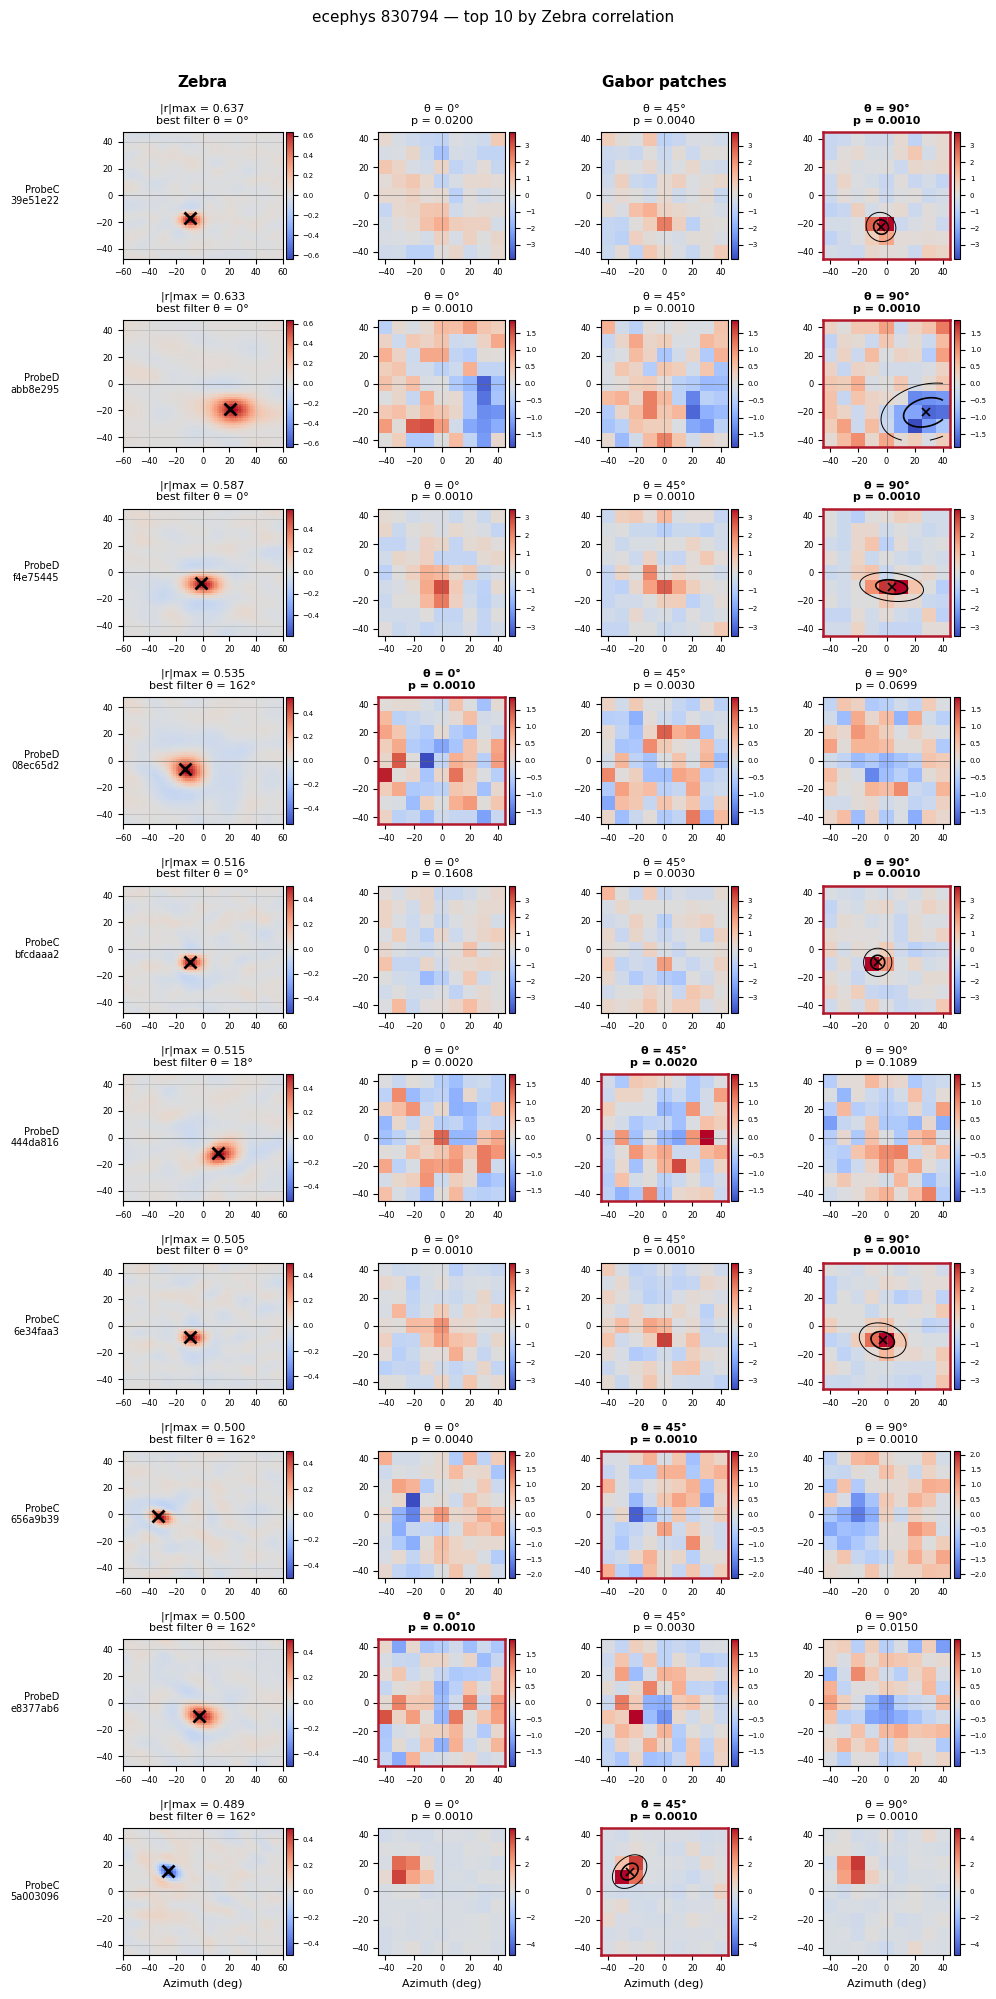


=== ecephys 830795 — top 10 by Zebra correlation ===
  group              unit   |r|max    Gabor p   |z|max
  ProbeC       78a87ef8-1    0.566          -        -
  ProbeC       7d1c1362-5    0.560          -        -
  ProbeC       73ecedf2-6    0.543          -        -
  ProbeC       eb70454f-1    0.457          -        -
  ProbeC       4d1b8ad5-9    0.445          -        -
  ProbeC       d6a62bfe-a    0.425          -        -
  ProbeC       1326f742-f    0.415          -        -
  ProbeA       f085fe36-1    0.411          -        -
  ProbeC       e39d8617-e    0.411          -        -
  ProbeC       dea4fe22-5    0.411          -        -
  -> compare_zebra_gabors__ecephys-830795__top10_by_zebra.csv  (10 rows)
  -> compare_zebra_gabors__ecephys-830795__top10_by_zebra.png


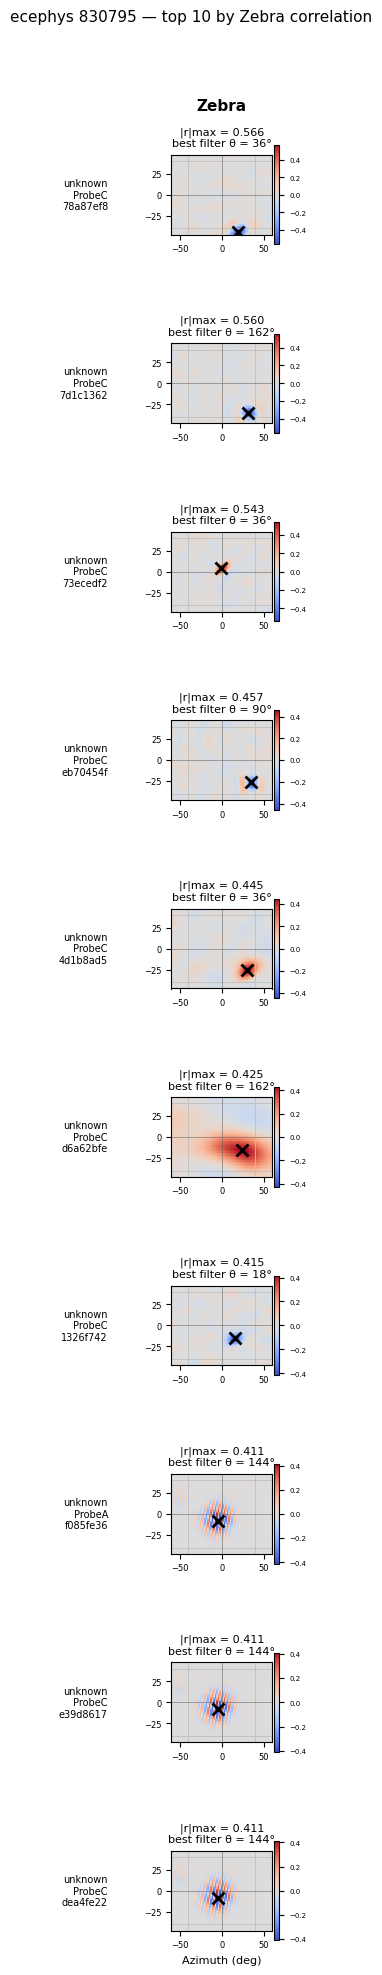


=== mesoscope 832700 — top 10 by Zebra correlation ===
  group              unit   |r|max    Gabor p   |z|max
  VISp_3               63    0.323     0.0010     2.38
  VISp_0               81    0.321     0.0040     1.96
  VISl_5              358    0.311     0.0010     2.94
  VISl_5              145    0.304     0.0010     3.24
  VISp_0               15    0.289     0.0090     2.60
  VISp_1               67    0.279     0.0420     2.17
  VISp_1               62    0.277     0.0010     2.71
  VISp_0               14    0.276     0.0010     4.06
  VISp_1               56    0.273     0.0380     1.76
  VISp_1              173    0.272     0.0110     3.69
  -> compare_zebra_gabors__mesoscope-832700__top10_by_zebra.csv  (10 rows)
  -> compare_zebra_gabors__mesoscope-832700__top10_by_zebra.png


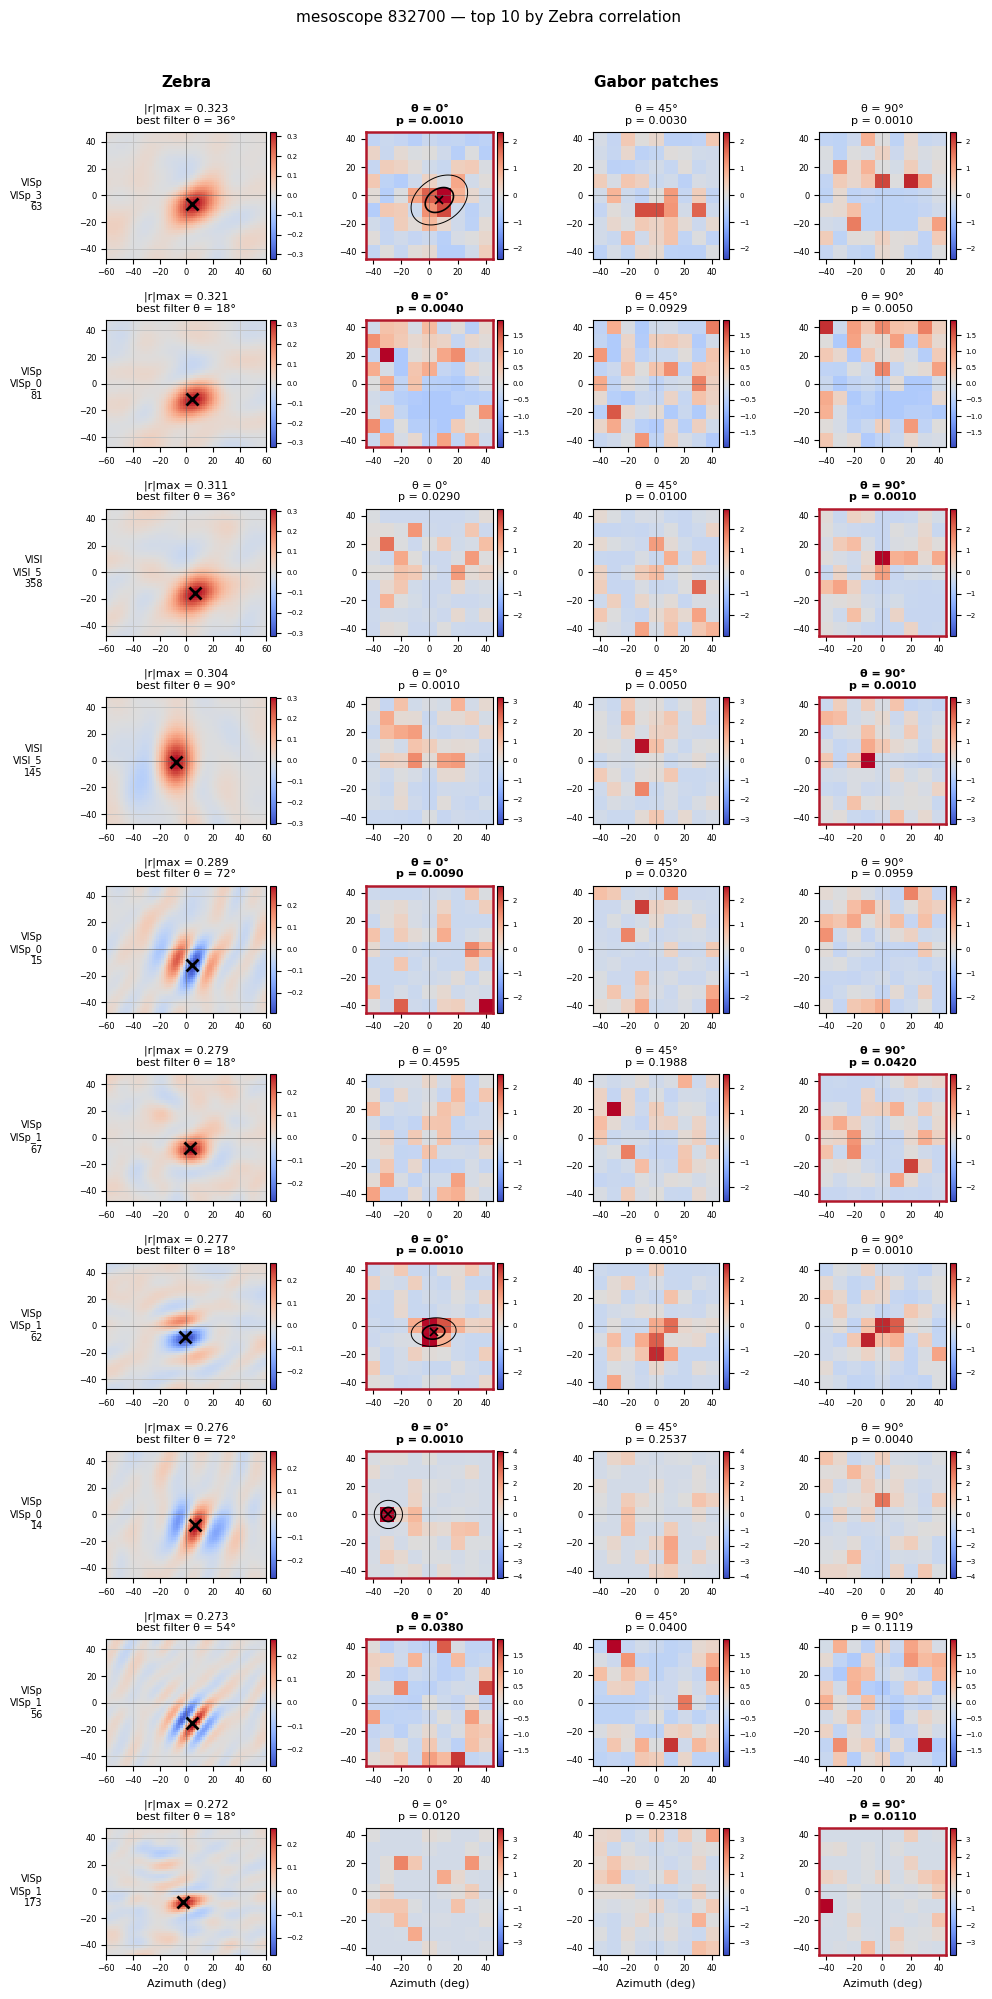


=== slap2 829704 green — top 10 by Zebra correlation ===
  group              unit   |r|max    Gabor p   |z|max
  DMD1__green          23    0.254     0.0030     2.89
  DMD1__green          19    0.237     0.1349     1.59
  DMD1__green          37    0.230     0.0010     2.89
  DMD2__green          25    0.225     0.0040     1.99
  DMD2__green          53    0.210     0.0110     2.24
  DMD1__green          28    0.207     0.0250     1.31
  DMD1__green          11    0.197     0.0080     1.73
  DMD1__green          43    0.194     0.0010     3.61
  DMD1__green          45    0.191     0.0210     2.08
  DMD1__green          10    0.190     0.0090     2.38
  -> compare_zebra_gabors__slap2-829704-green__top10_by_zebra.csv  (10 rows)
  -> compare_zebra_gabors__slap2-829704-green__top10_by_zebra.png


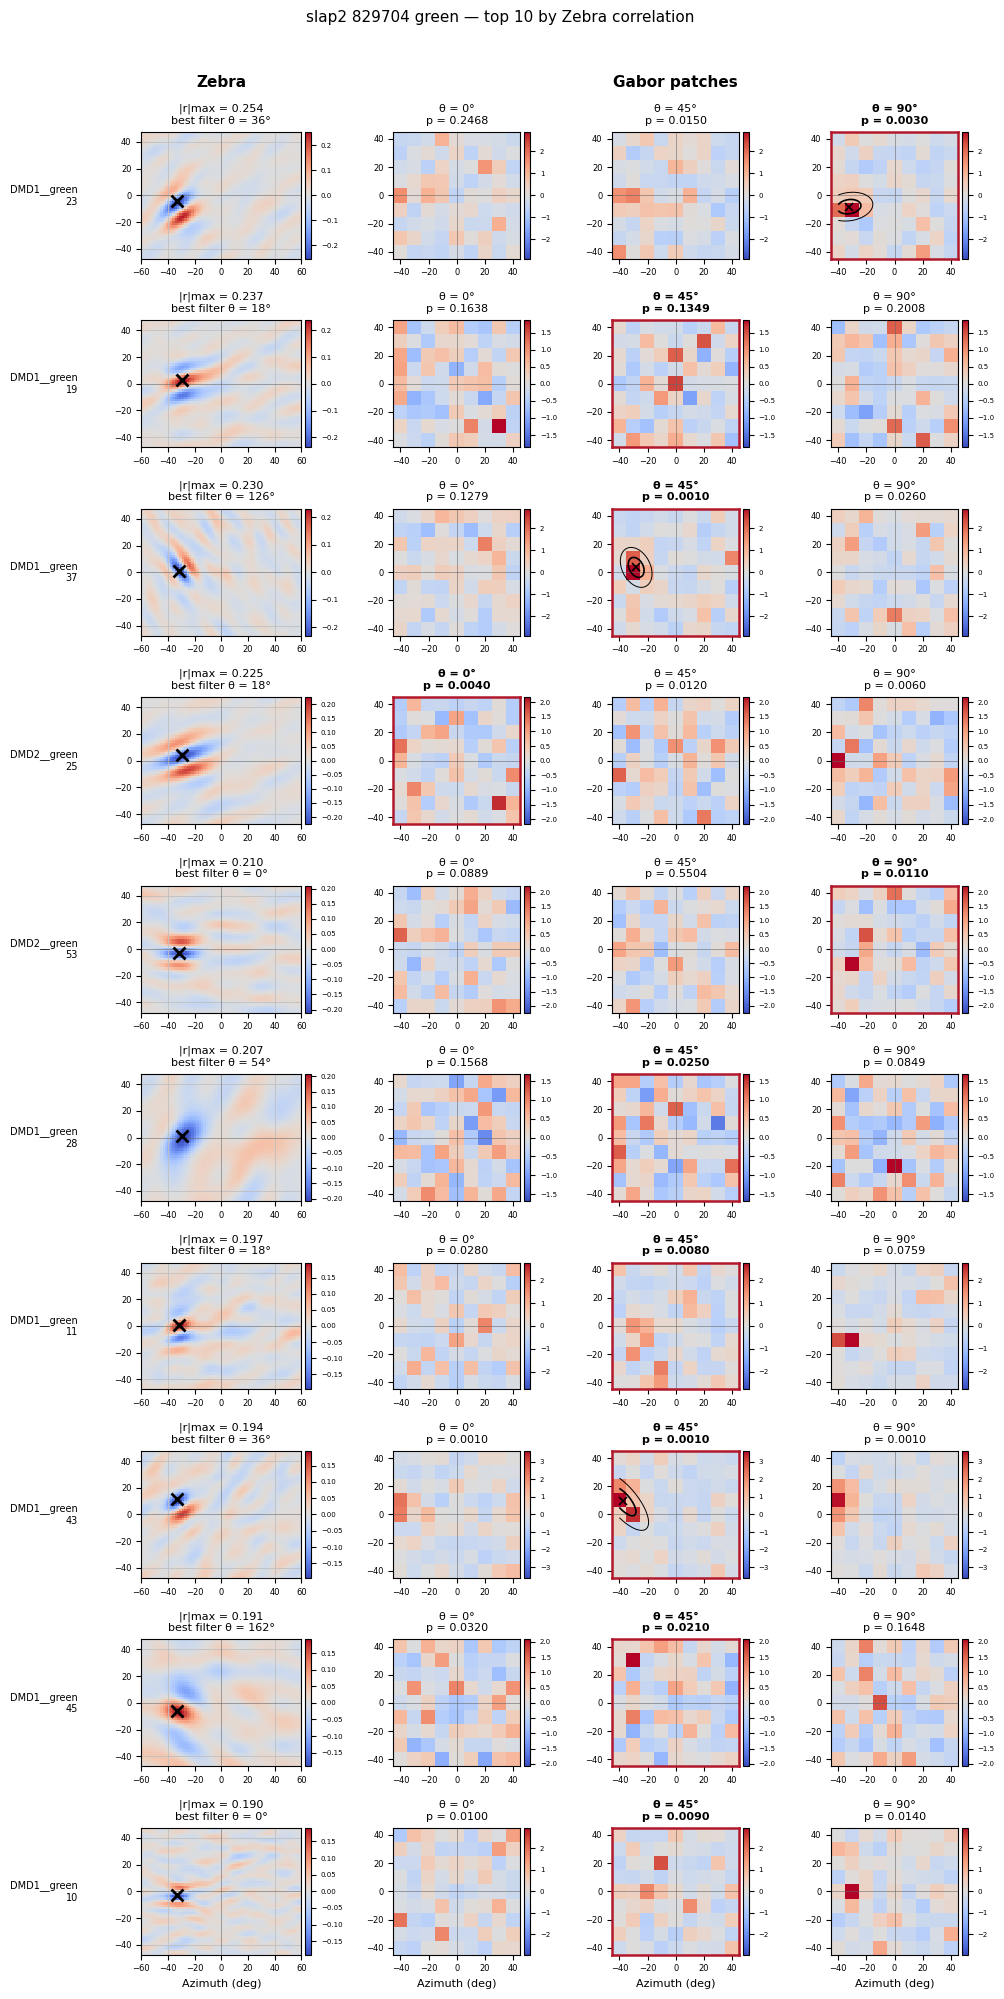


=== slap2 829704 red — top 10 by Zebra correlation ===
  group              unit   |r|max    Gabor p   |z|max
  DMD1__red            23    0.138     0.0450     1.81
  DMD2__red            16    0.129     0.0010     3.73
  DMD1__red            37    0.124     0.0020     4.74
  DMD2__red             0    0.119     0.0509     2.32
  DMD1__red            19    0.119     0.0400     3.11
  DMD2__red            53    0.118     0.0420     1.56
  DMD2__red            10    0.112     0.0839     2.15
  DMD1__red            18    0.110     0.0190     2.41
  DMD2__red            72    0.109     0.0030     2.80
  DMD2__red             5    0.109     0.0030     3.19
  -> compare_zebra_gabors__slap2-829704-red__top10_by_zebra.csv  (10 rows)
  -> compare_zebra_gabors__slap2-829704-red__top10_by_zebra.png


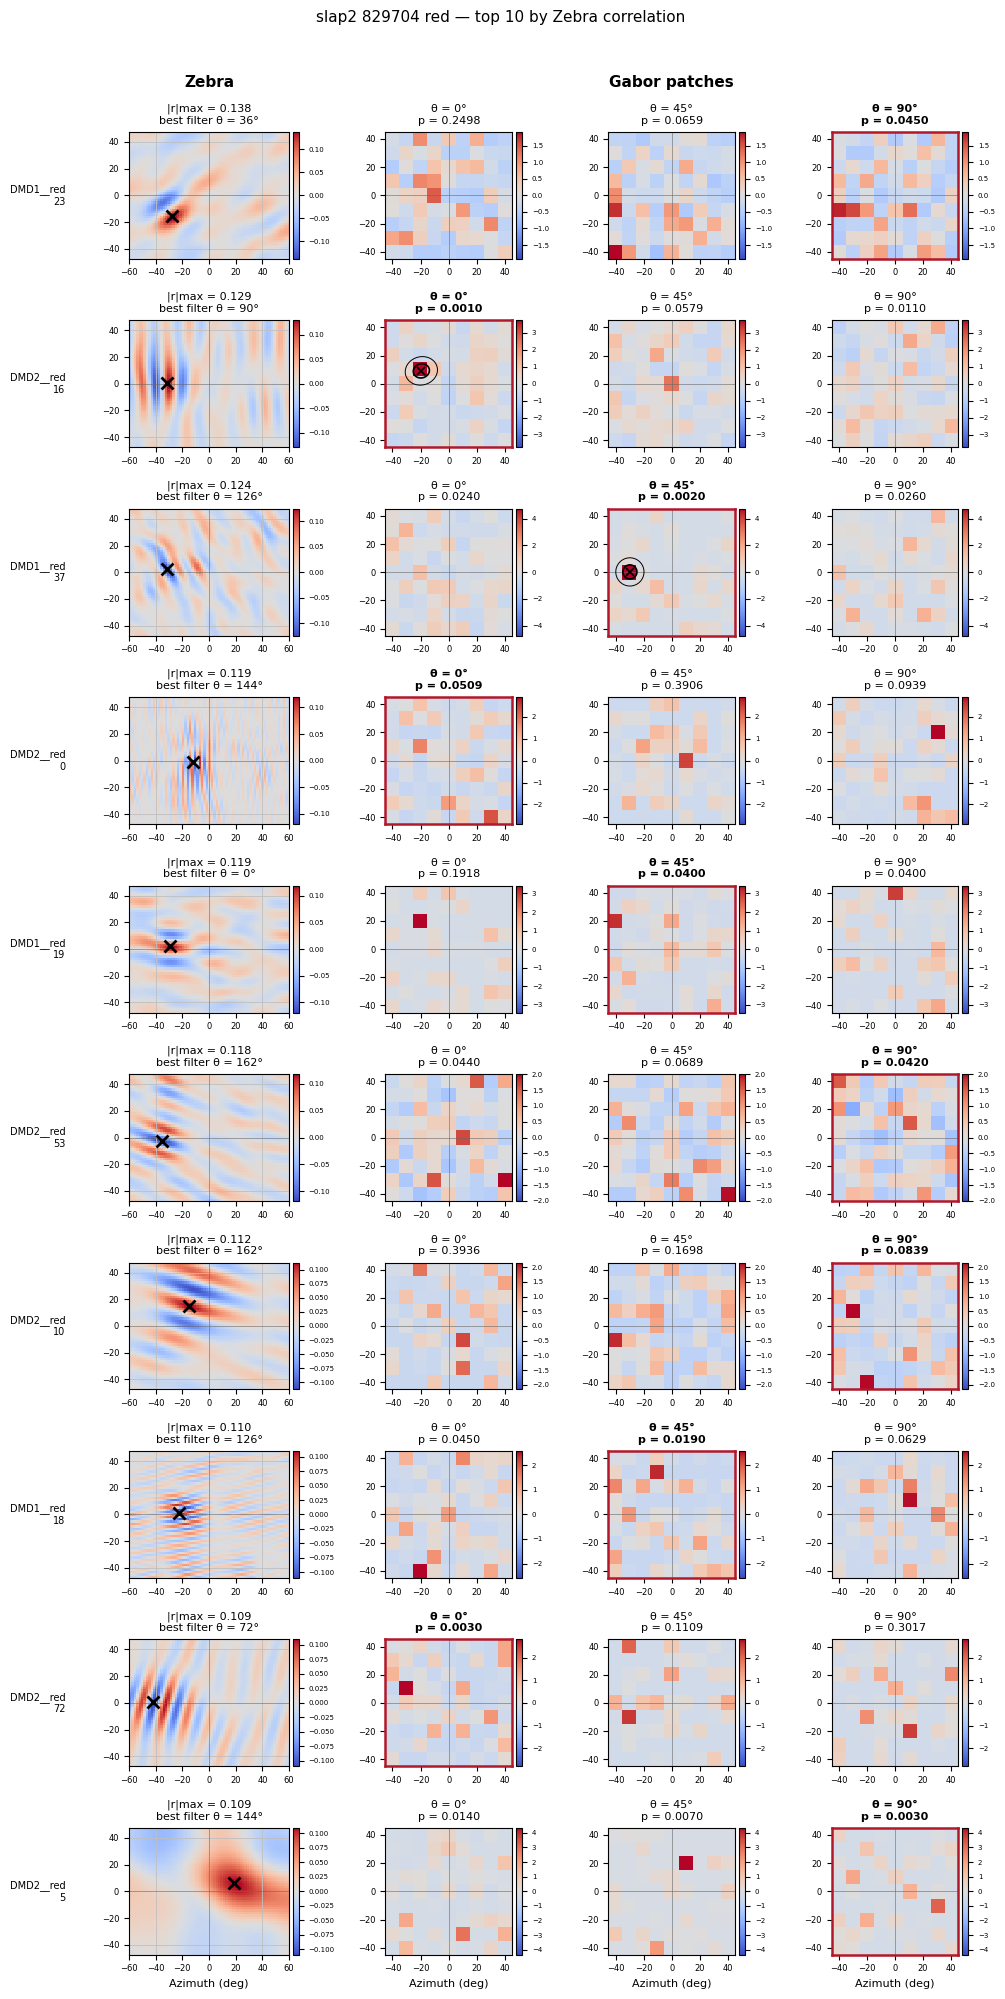

In [104]:
figs_a = {}
for label, df in paired.items():
    stem = f'{slug(label)}__top{N_TOP}_by_zebra'
    top = report(df, f'\n=== {label} — top {N_TOP} by Zebra correlation ===',
                 ['abs_max_value'], ascending=[False])
    save_table(top, stem)
    figs_a[label] = plot_rf_pairs(top, f'{label} — top {N_TOP} by Zebra correlation',
                                  df.attrs['extent'], df.attrs['orientations'],
                                  label, fits_by_unit, location_by_unit)
    save_figure(figs_a[label], stem)
    plt.show()

## Selection B — the 10 best Gabor-patch p-values, per session

Ranked by the p-value of each unit's best orientation. With `n_shuffle`
permutations the smallest attainable p-value is `1 / (n_shuffle + 1)`, so ties
at the floor are expected once several units are clearly significant — the
order among them is arbitrary.


=== ecephys 830794 — top 10 by Gabor-patch p-value ===
  group              unit   |r|max    Gabor p   |z|max
  ProbeC       eebf7ac2-b    0.126     0.0010     6.88
  ProbeC       259448b1-a    0.265     0.0010     6.55
  ProbeD       e9251eda-c    0.189     0.0010     6.40
  ProbeC       c861bcc7-9    0.366     0.0010     6.04
  ProbeD       f2eabb48-3    0.124     0.0010     5.96
  ProbeC       2a1ab9e5-3    0.265     0.0010     5.72
  ProbeC       0226dedb-f    0.300     0.0010     5.70
  ProbeC       bb19d443-b    0.135     0.0010     5.67
  ProbeD       90a81561-6    0.142     0.0010     5.65
  ProbeC       9f732558-0    0.134     0.0010     5.64
  p floor = 0.000999  (inferred from the data, implying n_shuffle≈1000); 10 of 10 shown sit on it, and so do 1192 of 3988 units overall — the order among them is by |z|max, not by p
  -> compare_zebra_gabors__ecephys-830794__top10_by_gabor_p.csv  (10 rows)
  -> compare_zebra_gabors__ecephys-830794__top10_by_gabor_p.png


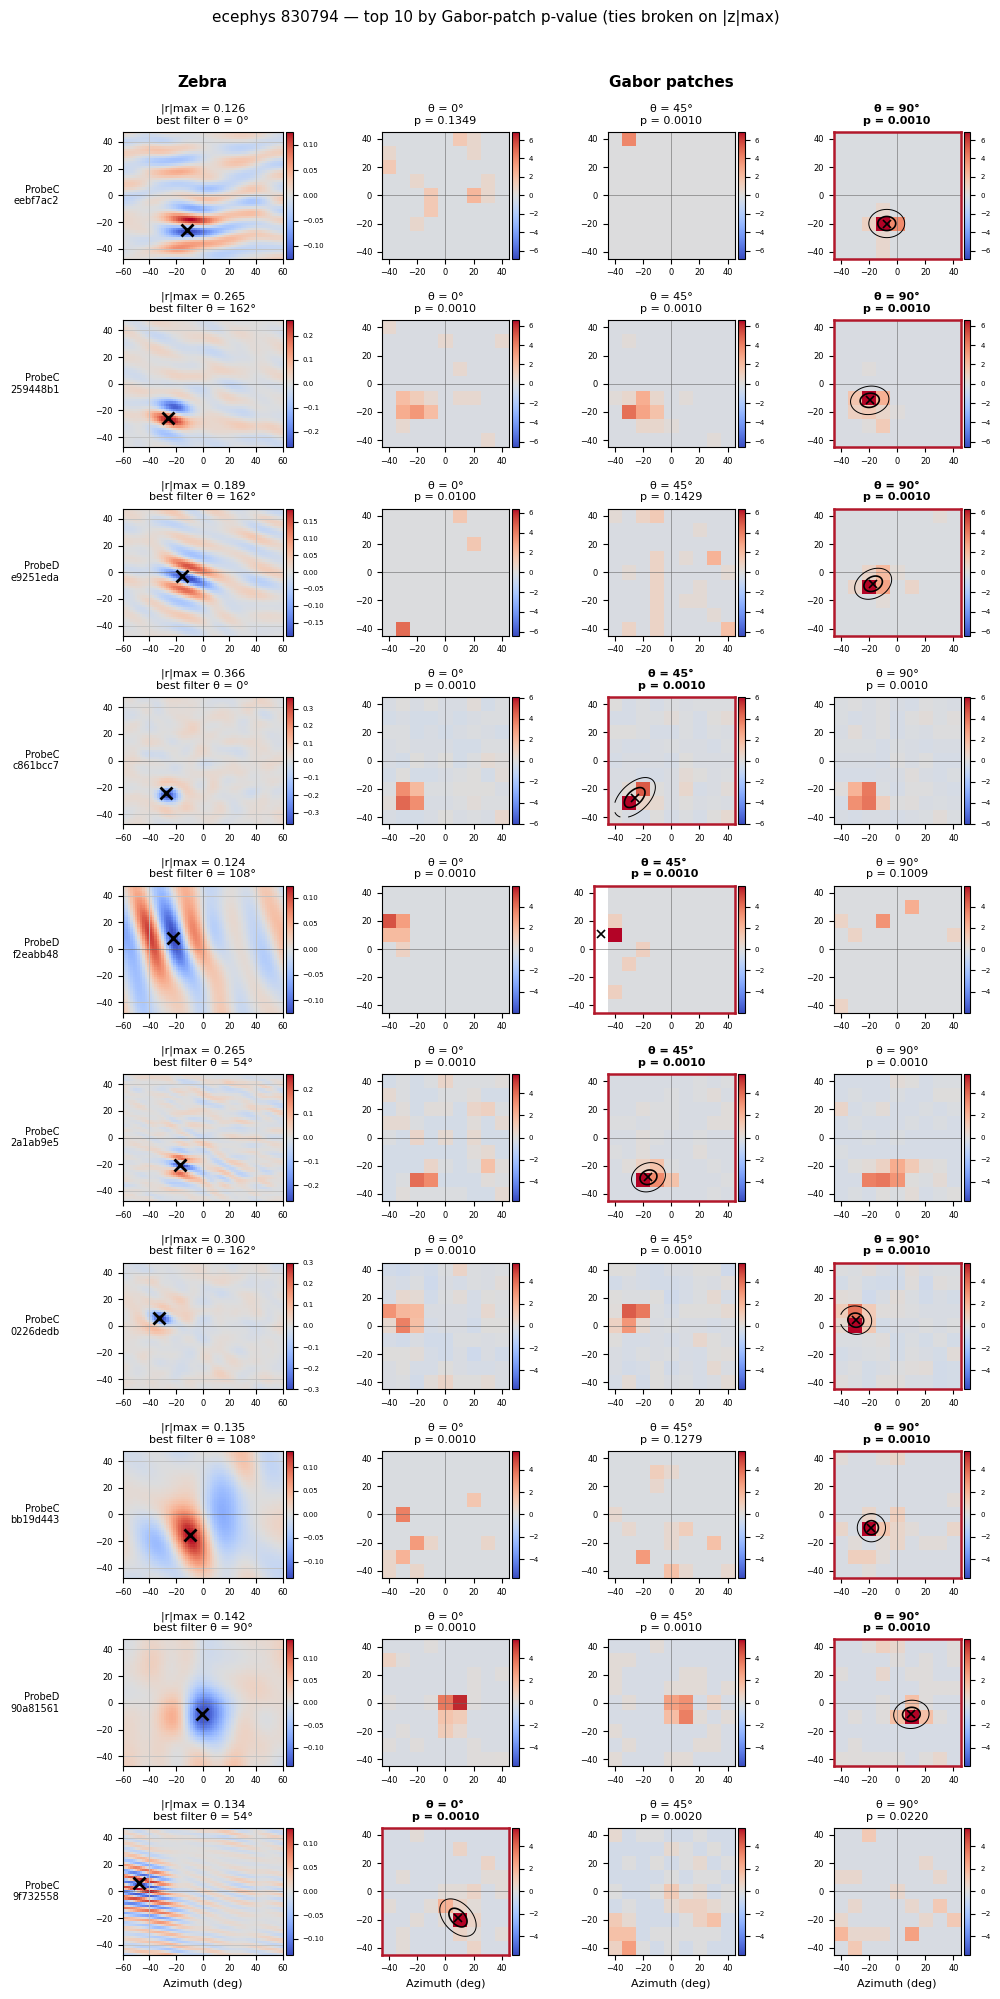


=== ecephys 830795 — top 10 by Gabor-patch p-value ===: nothing to rank (3440 units, none carrying p_value + z_max)
  -> compare_zebra_gabors__ecephys-830795__top10_by_gabor_p.csv  (0 rows)
  -> compare_zebra_gabors__ecephys-830795__top10_by_gabor_p.png


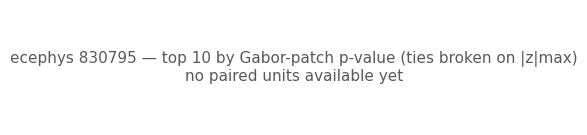


=== mesoscope 832700 — top 10 by Gabor-patch p-value ===
  group              unit   |r|max    Gabor p   |z|max
  VISl_4              151    0.097     0.0010     7.97
  VISp_1              473    0.139     0.0010     7.72
  VISl_4               26    0.114     0.0010     7.68
  VISp_1              153    0.222     0.0010     7.48
  VISp_0              338    0.153     0.0010     7.47
  VISp_0              372    0.096     0.0010     7.45
  VISp_0               26    0.100     0.0010     7.38
  VISp_0              337    0.151     0.0010     7.37
  VISp_0              109    0.191     0.0010     7.34
  VISp_1               36    0.227     0.0010     7.33
  p floor = 0.000999  (n_shuffle=1000); 10 of 10 shown sit on it, and so do 1166 of 2458 units overall — the order among them is by |z|max, not by p
  -> compare_zebra_gabors__mesoscope-832700__top10_by_gabor_p.csv  (10 rows)
  -> compare_zebra_gabors__mesoscope-832700__top10_by_gabor_p.png


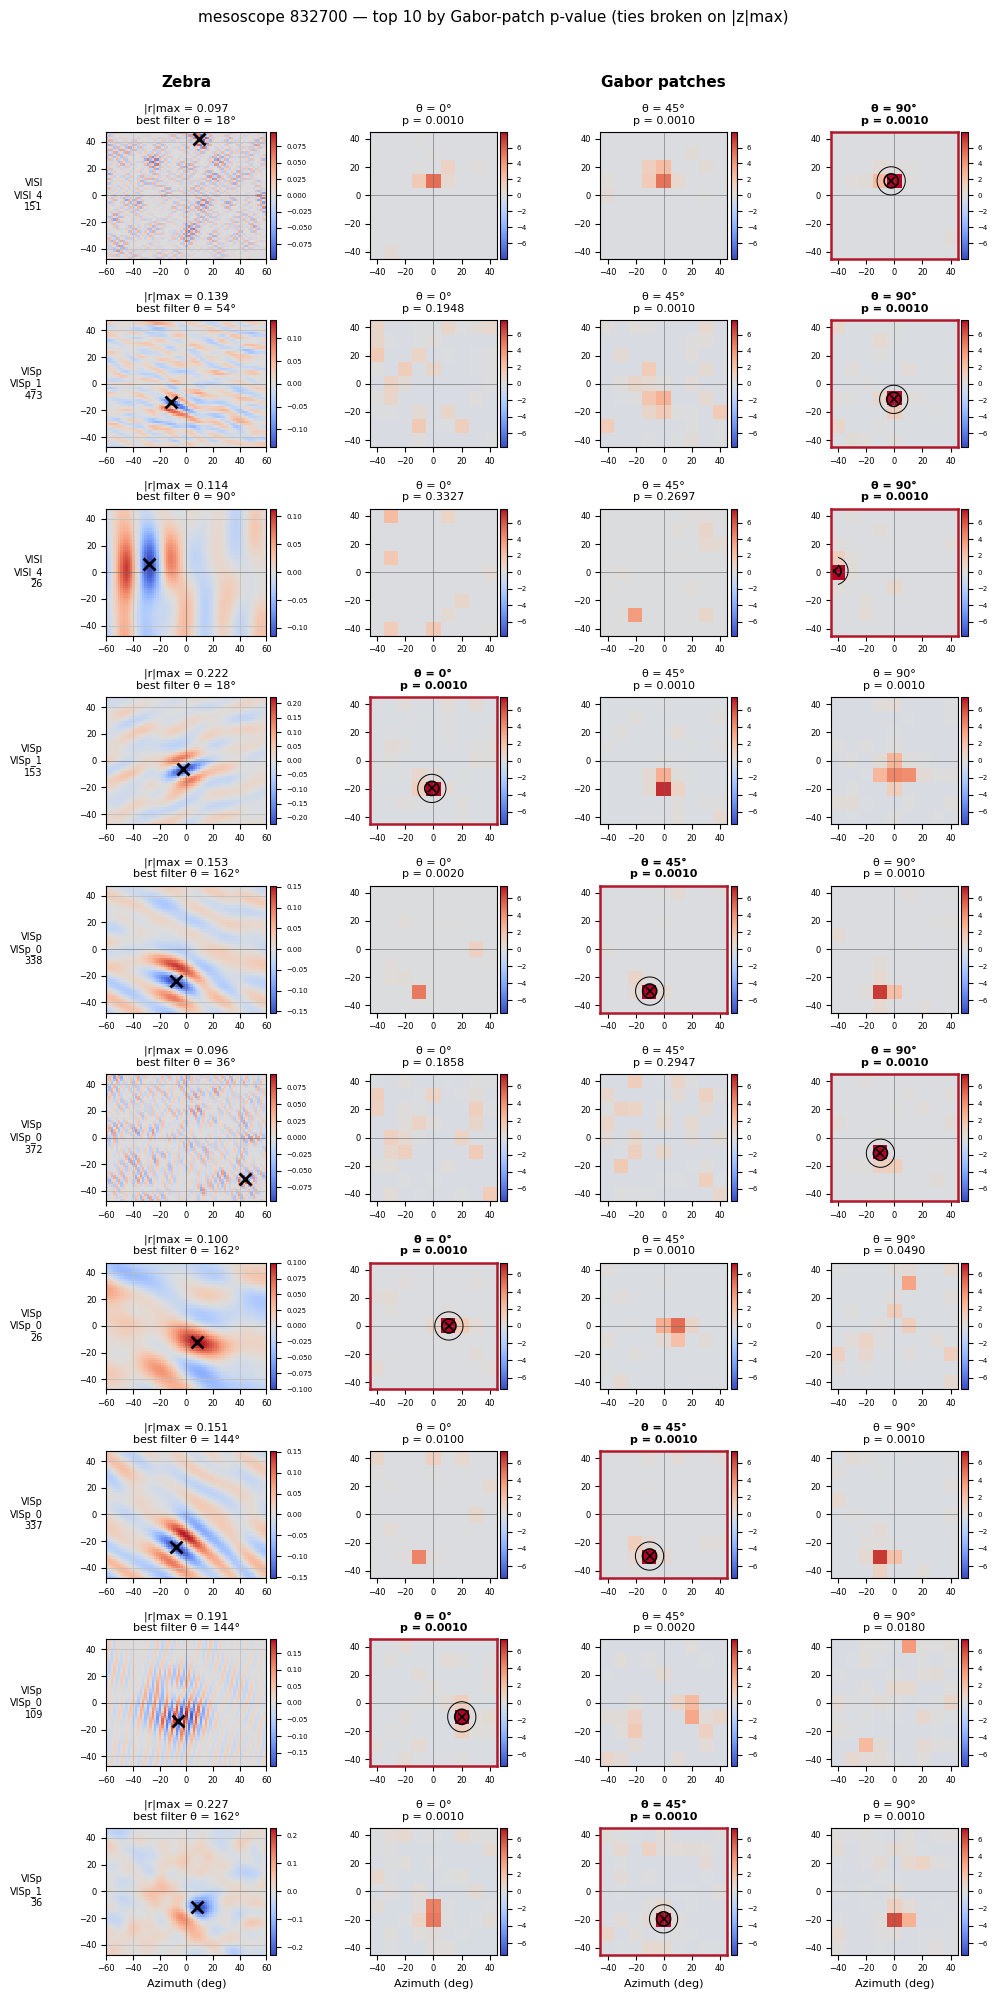


=== slap2 829704 green — top 10 by Gabor-patch p-value ===
  group              unit   |r|max    Gabor p   |z|max
  DMD2__green          19    0.156     0.0010     4.61
  DMD1__green          43    0.194     0.0010     3.61
  DMD1__green          39    0.118     0.0010     3.45
  DMD2__green          62    0.085     0.0010     3.26
  DMD2__green          23    0.085     0.0010     3.25
  DMD1__green          37    0.230     0.0010     2.89
  DMD2__green          16    0.160     0.0010     2.26
  DMD2__green          42    0.076     0.0010     2.16
  DMD1__green           7    0.081     0.0010     1.69
  DMD2__green          12    0.086     0.0020     2.69
  p floor = 0.000999  (n_shuffle=1000); 9 of 10 shown sit on it, and so do 9 of 125 units overall — the order among them is by |z|max, not by p
  -> compare_zebra_gabors__slap2-829704-green__top10_by_gabor_p.csv  (10 rows)
  -> compare_zebra_gabors__slap2-829704-green__top10_by_gabor_p.png


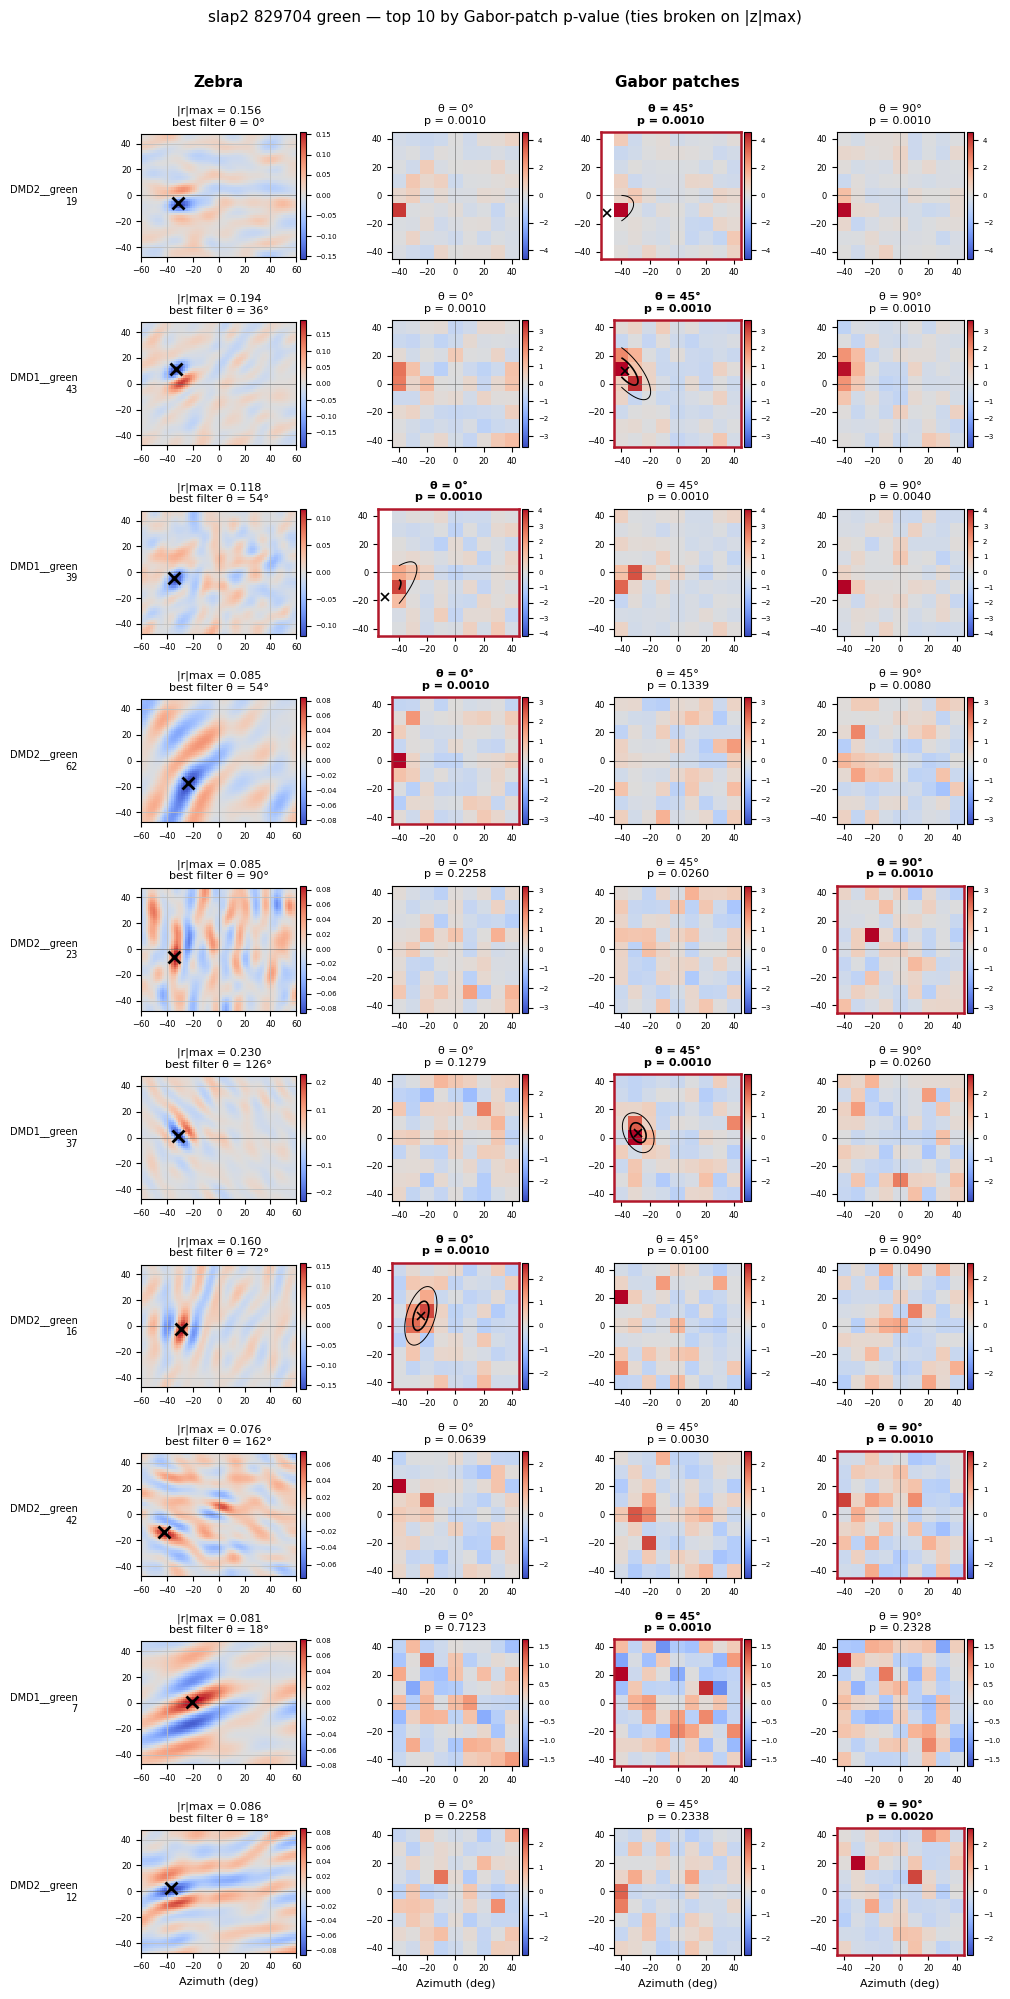


=== slap2 829704 red — top 10 by Gabor-patch p-value ===
  group              unit   |r|max    Gabor p   |z|max
  DMD2__red            16    0.129     0.0010     3.73
  DMD2__red             8    0.098     0.0010     3.34
  DMD1__red            41    0.087     0.0010     2.96
  DMD2__red            32    0.087     0.0010     1.98
  DMD1__red            43    0.082     0.0010     1.65
  DMD1__red            37    0.124     0.0020     4.74
  DMD2__red            19    0.087     0.0020     3.91
  DMD2__red            29    0.094     0.0020     3.15
  DMD1__red             9    0.087     0.0020     2.50
  DMD1__red            38    0.076     0.0020     2.44
  p floor = 0.000999  (n_shuffle=1000); 5 of 10 shown sit on it, and so do 5 of 125 units overall — the order among them is by |z|max, not by p
  -> compare_zebra_gabors__slap2-829704-red__top10_by_gabor_p.csv  (10 rows)
  -> compare_zebra_gabors__slap2-829704-red__top10_by_gabor_p.png


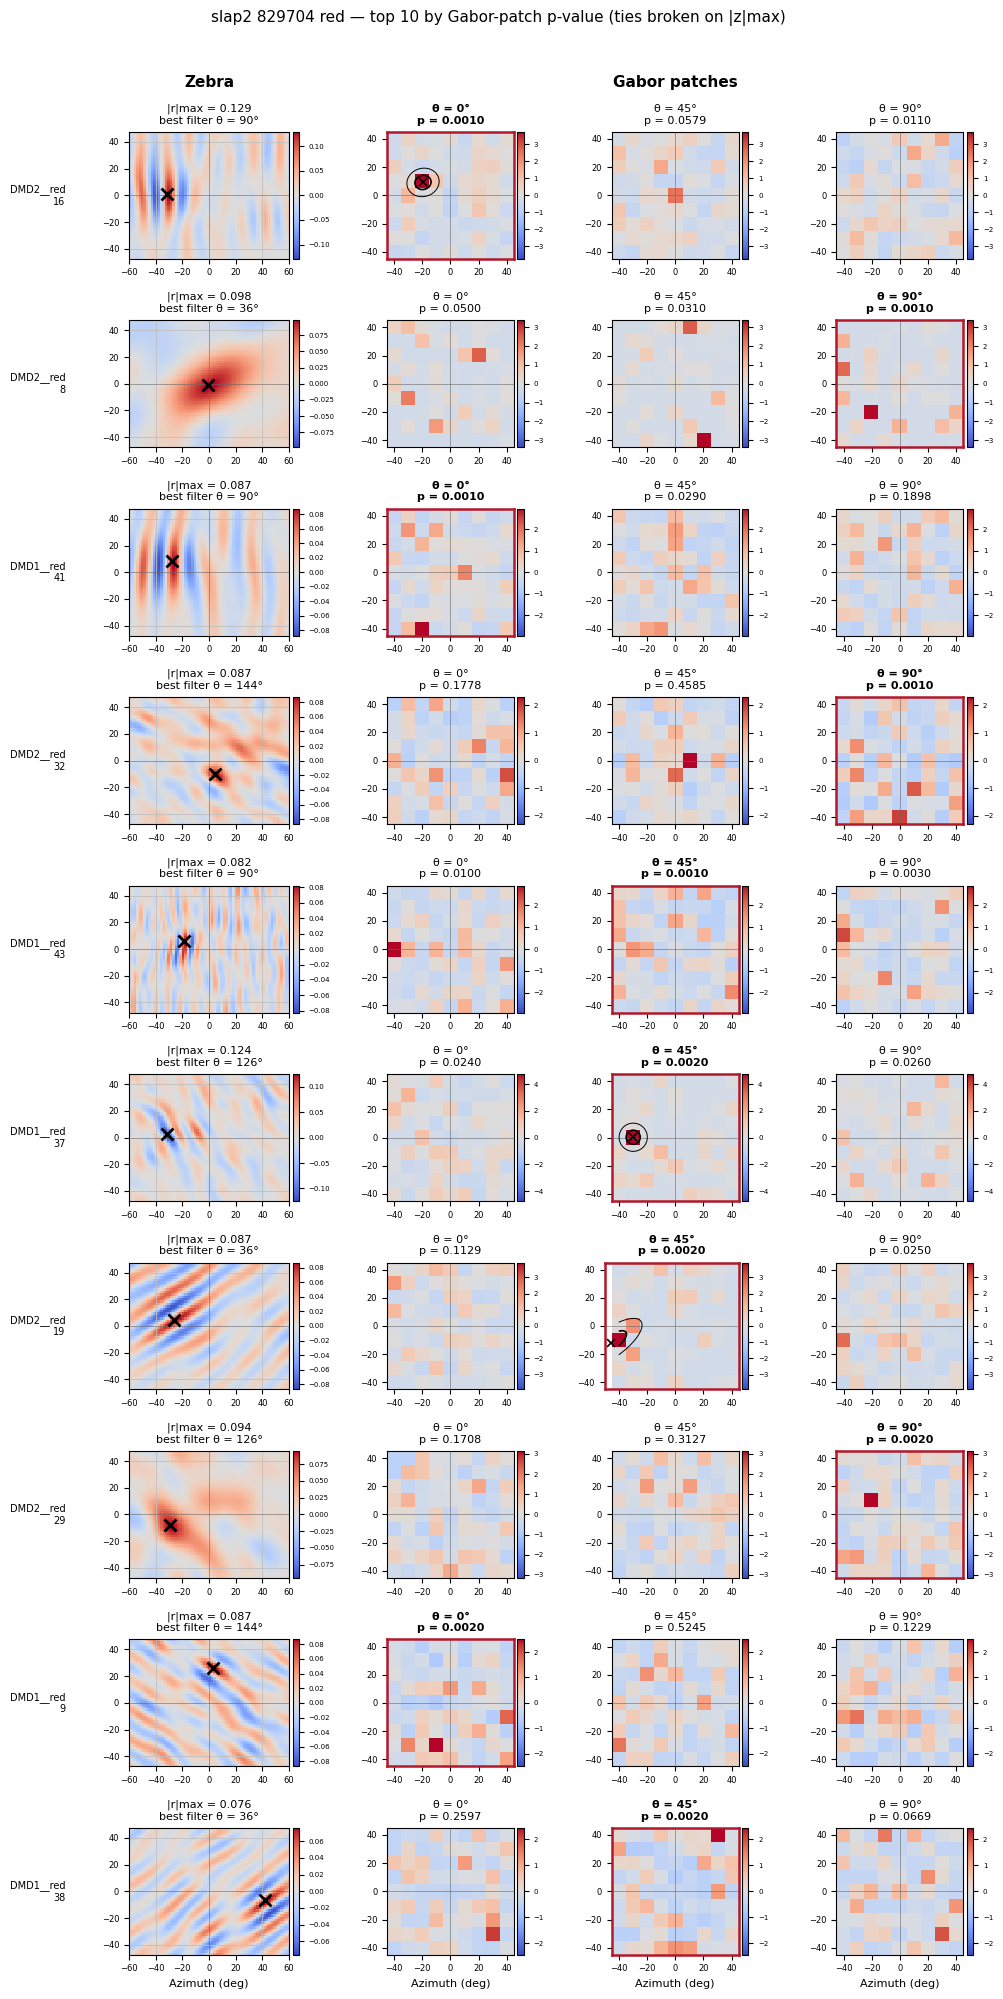

In [105]:
figs_b = {}
for label, df in paired.items():
    # The SLAP2/mesoscope files record n_shuffle; the ecephys ones do not. Their
    # p-values are still quantised in steps of 1/(n_shuffle+1), so the floor is
    # recoverable as the smallest value present — flagged as inferred either way.
    n_sh = df.attrs.get('n_shuffle', 0)
    if n_sh:
        floor, how = 1.0 / (n_sh + 1), f'n_shuffle={n_sh}'
    elif df['p_value'].notna().any():
        floor = float(df['p_value'].min())
        how = f'inferred from the data, implying n_shuffle≈{round(1 / floor) - 1}'
    else:
        floor, how = np.nan, ''

    stem = f'{slug(label)}__top{N_TOP}_by_gabor_p'
    top = report(df, f'\n=== {label} — top {N_TOP} by Gabor-patch p-value ===',
                 ['p_value', 'z_max'], ascending=[True, False])
    if len(top) and np.isfinite(floor):
        n_at_floor = int((top['p_value'] <= floor + 1e-12).sum())
        n_tied = int((df['p_value'] <= floor + 1e-12).sum())
        n_with_p = int(df['p_value'].notna().sum())
        print(f'  p floor = {floor:.4g}  ({how})' +
              (f'; {n_at_floor} of {len(top)} shown sit on it, and so do {n_tied} '
               f'of {n_with_p} units overall — the order among them is by |z|max, '
               'not by p' if n_at_floor > 1 else ''))
    save_table(top, stem)
    figs_b[label] = plot_rf_pairs(top,
                                  f'{label} — top {N_TOP} by Gabor-patch p-value (ties broken on |z|max)',
                                  df.attrs['extent'], df.attrs['orientations'],
                                  label, fits_by_unit, location_by_unit)
    save_figure(figs_b[label], stem)
    plt.show()

## How much do the two rankings agree?

A negative Spearman means the pipelines agree: a stronger Zebra correlation
goes with a smaller Gabor-patch p-value.

In [106]:
rows = []
for label, df in paired.items():
    both = df.dropna(subset=['abs_max_value', 'p_value']) if len(df) else df
    if len(both) > 2:
        sel_a = both.nlargest(N_TOP, 'abs_max_value')
        top_a = set(sel_a['unit_id'].astype(str) + '@' + sel_a['group'])
        sel_b = both.sort_values(['p_value', 'z_max'], ascending=[True, False]).head(N_TOP)
        top_b = set(sel_b['unit_id'].astype(str) + '@' + sel_b['group'])
        rows.append({'session': label, 'units': len(df), 'both_pipelines': len(both),
                     'groups': df['group'].nunique(),
                     'top10_overlap': len(top_a & top_b),
                     'spearman': both['abs_max_value'].corr(both['p_value'], method='spearman')})
    else:
        rows.append({'session': label, 'units': len(df), 'both_pipelines': len(both),
                     'groups': int(df['group'].nunique()) if len(df) else 0,
                     'top10_overlap': np.nan, 'spearman': np.nan})

pd.DataFrame(rows).set_index('session')

,units,both_pipelines,groups,top10_overlap,spearman
session,,,,,
ecephys 830794,3988,3988,6,0.0,-0.202002
ecephys 830795,3440,0,6,NaN,NaN
mesoscope 832700,2458,2458,8,0.0,-0.099085
slap2 829704 green,125,125,2,2.0,-0.044745
slap2 829704 red,125,125,2,2.0,-0.012714


In [107]:
import glob
import pandas as pd

loaded_csvs = [pd.read_csv(f) for f in glob.glob('../plots/*.csv')]
pd.concat(loaded_csvs)

,rank,group,unit_id,abs_max_value,p_value,z_max,delay_zebra,duration_zebra,x_deg,y_deg,...,amp,railed,edge,sigma_resolution,abs_max_value_dff,abs_max_value_events,delay_dff,duration_dff,delay_events,duration_events
0,1,ProbeC,78a87ef8-121b-4291-83c9-a205e29550b8,0.565659,NaN,NaN,0.01,0.08,18.80597,-43.915094,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,ProbeC,7d1c1362-5f11-4967-9287-3a14e8138ca1,0.55957,NaN,NaN,0.0,0.08,31.343284,-34.95283,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,ProbeC,73ecedf2-6f52-4013-8698-4319ef76a7f9,0.54334,NaN,NaN,0.0,0.08,-0.895522,4.481132,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,ProbeC,eb70454f-123f-4664-8dab-796f5dccf2fb,0.456719,NaN,NaN,0.01,0.08,34.925373,-25.990566,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,ProbeC,4d1b8ad5-9a5e-42f5-92be-06a387f718f2,0.445387,NaN,NaN,0.02,0.08,29.552239,-25.990566,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1,DMD1__red,23,0.137847,0.015984,1.891581,0.1,0.1,-27.761194,-15.235849,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,DMD2__red,16,0.128874,0.000999,3.67843,0.1,0.1,-31.343284,0.896226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,DMD1__red,37,0.124456,0.004995,2.333796,0.1,0.1,-31.343284,2.688679,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,DMD2__red,0,0.119026,0.042957,2.137672,0.3,0.25,-11.641791,-0.896226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
files = glob.glob('../plots/*.csv')
pd.read_csv(files[1])

,rank,group,unit_id,abs_max_value,p_value,z_max,delay_zebra,duration_zebra,x_deg,y_deg,theta_rad,theta_deg,sigma_deg,frequency,ori_idx,ori_rad,delay_gabor,duration_gabor
0,1,VISp_3,63,0.323288,0.000999,2.375914,0.15,0.0,4.477612,-6.273585,0.628319,45.022513,17.91,0.03,0,0.000000,0.2,0.50
1,2,VISp_0,81,0.321335,0.003996,1.955268,0.15,0.0,4.477612,-11.650943,0.314159,22.515924,17.91,0.03,0,0.000000,0.0,0.50
2,3,VISl_5,358,0.311384,0.000999,2.943324,0.12,0.0,6.268657,-15.235849,0.628319,45.022513,17.91,0.03,2,1.570796,0.0,0.25
3,4,VISl_5,145,0.304072,0.000999,3.240609,0.12,0.0,-8.059701,-0.896226,1.570796,112.484085,21.49,0.03,2,1.570796,0.3,1.00
4,5,VISp_0,15,0.289476,0.008991,2.602767,0.12,0.0,4.477612,-11.650943,1.256637,90.000000,17.91,0.07,0,0.000000,0.3,0.25
5,6,VISp_1,67,0.278889,0.041958,2.170241,0.15,0.0,2.686567,-8.066038,0.314159,22.515924,10.74,0.04,2,1.570796,0.0,0.25
6,7,VISp_1,62,0.277392,0.000999,2.712169,0.12,0.0,-0.895522,-8.066038,0.314159,22.515924,14.32,0.06,0,0.000000,0.3,0.50
7,8,VISp_0,14,0.276474,0.000999,4.055087,0.15,0.0,6.268657,-8.066038,1.256637,90.000000,17.91,0.06,0,0.000000,0.1,0.25
8,9,VISp_1,56,0.273149,0.037962,1.764998,0.12,0.0,4.477612,-15.235849,0.942478,67.515915,17.91,0.10,0,0.000000,0.1,0.50
9,10,VISp_1,173,0.271773,0.010989,3.690799,0.09,0.2,-2.686567,-8.066038,0.314159,22.515924,10.74,0.08,2,1.570796,0.3,0.25


## Receptive-field position heatmap, by modality

Where RF centres cluster across the population: a 3x2 grid, one row per
modality and one column per pipeline. The two ecephys sessions are pooled
into one `ecephys` row and the two SLAP2 channels into one `slap2` row —
`mesoscope` is already a single session. Pooling is safe here in a way it
isn't for the ranked selections above: those compare a *statistic*
(correlation vs p-value) across units, where mixing sessions or indicators
would blend incomparable scales, but a position in visual degrees means the
same thing regardless of which session or channel it came from.

**Zebra** position is `x_deg`/`y_deg` — the position of `abs_max_value`
itself, the same value the cross overlay in Selections A/B marks — for every
unit with `abs_max_value > ZEBRA_R_THRESH`.

**Gabor-patch** position is the fitted Gaussian envelope's centroid
(`x0`/`y0`, read back from the cached fits above rather than refit) for
every unit with `p_value <= FIT_P_THRESH`. A unit imaged on both SLAP2
channels (same DMD, same ROI, once per indicator) can clear that threshold
under both, so it would otherwise count twice in the `slap2` row; the
higher-|z| channel wins, the same tie-break Selections A/B already use to
pick a unit's single best orientation.


  -> compare_zebra_gabors__rf_position_heatmap.png


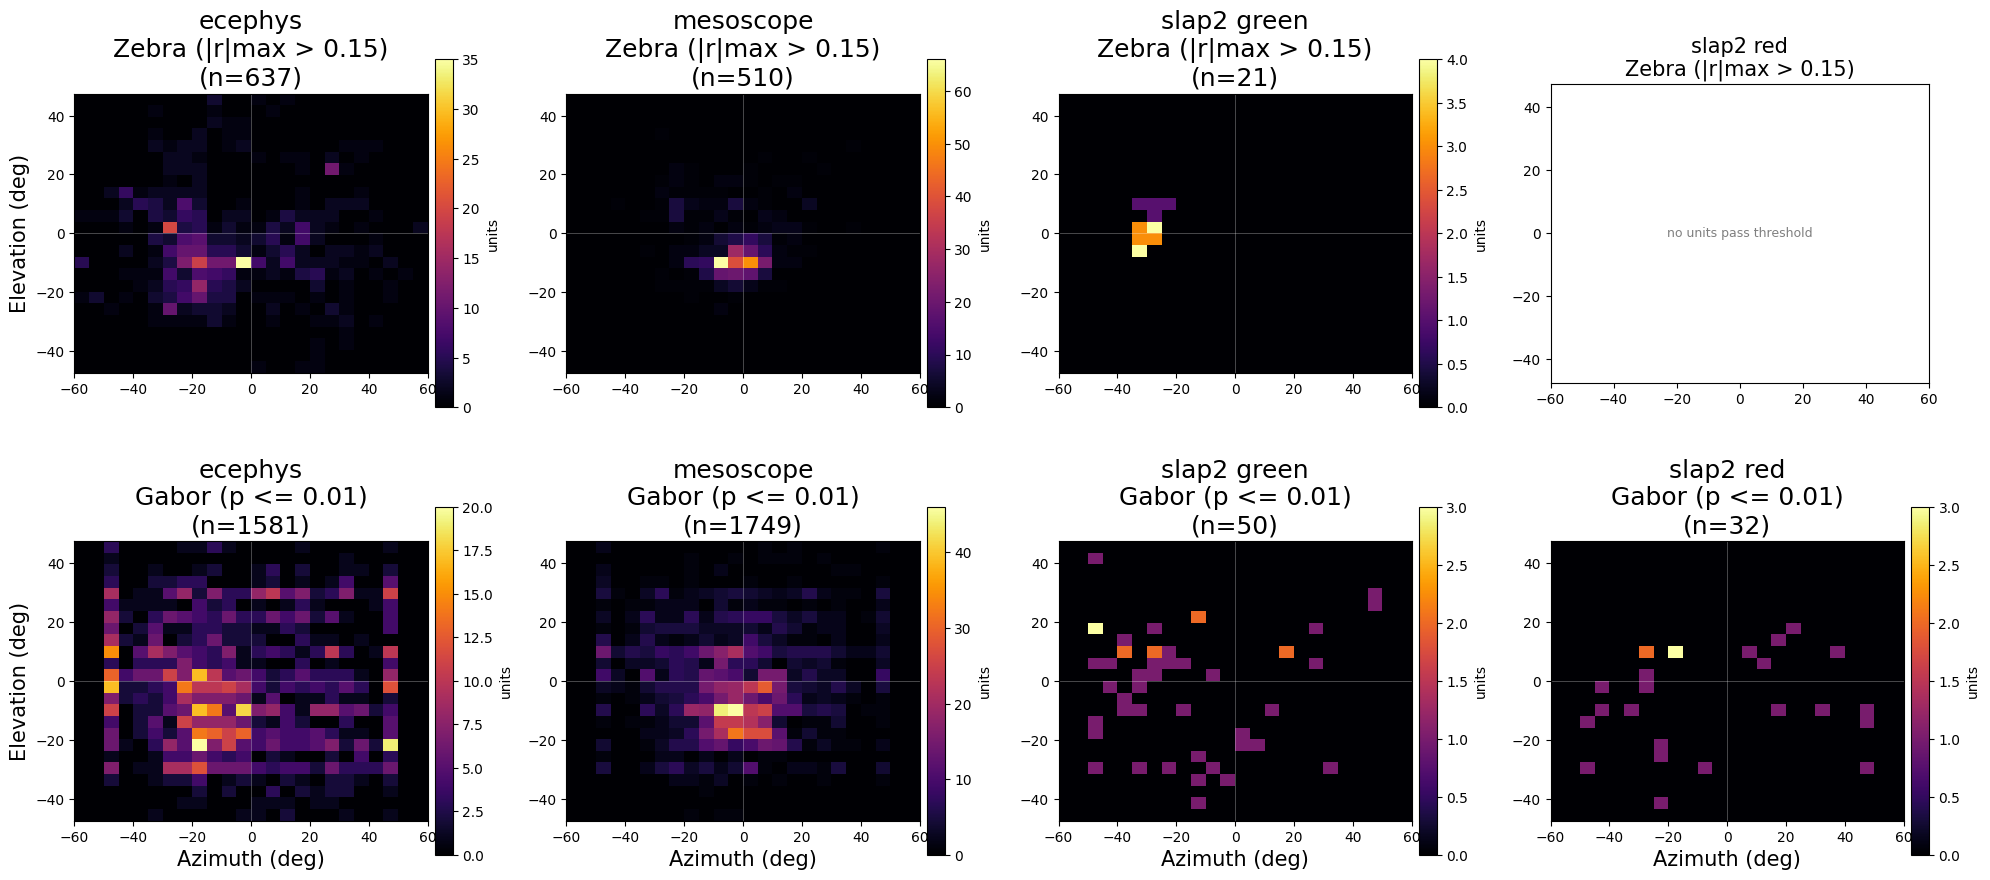

In [114]:
MODALITY_LABELS = {
    'ecephys':     [l for l in SESSIONS if l.startswith('ecephys')],
    'mesoscope':   [l for l in SESSIONS if l.startswith('mesoscope')],
    'slap2 green': [l for l in SESSIONS if l.startswith('slap2') and l.endswith('green')],
    'slap2 red':   [l for l in SESSIONS if l.startswith('slap2') and l.endswith('red')],
}
ZEBRA_R_THRESH = 0.15


def zebra_rf_positions(labels):
    """(x_deg, y_deg) of abs_max_value itself, pooled over `labels`, |r|max > ZEBRA_R_THRESH."""
    frames = [paired[l] for l in labels if l in paired and len(paired[l])]
    if not frames:
        return np.array([]), np.array([])
    d = pd.concat(frames, ignore_index=True)
    d = d[d['abs_max_value'] > ZEBRA_R_THRESH]
    return d['x_deg'].to_numpy(), d['y_deg'].to_numpy()


def gabor_rf_positions(labels):
    """(x0, y0) -- the fitted envelope's centroid -- pooled over `labels`, p <= FIT_P_THRESH.

    `fits_loaded` already carries one row per unit's single best orientation
    (load_gabor's own p-then-z tie-break); the only duplicate left to resolve
    here is a unit imaged on both SLAP2 channels, collapsed to the higher-|z|
    channel by that same rule.
    """
    d = fits_loaded[fits_loaded['label'].isin(labels)
                    & (fits_loaded['p_value'] <= FIT_P_THRESH)
                    & fits_loaded['success'].astype(bool)].copy()
    if not len(d):
        return np.array([]), np.array([])
    d['base_group'] = d['group'].str.split('__').str[0]
    d = d.sort_values('z_max', ascending=False).drop_duplicates(
        subset=['base_group', 'unit_id'], keep='first')
    return d['x0'].to_numpy(), d['y0'].to_numpy()


def plot_rf_heatmap(fig, ax, x, y, extent, title, bins=24):
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
    ax.set_aspect('equal')
    if len(x) == 0:
        ax.text(.5, .5, 'no units pass threshold', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='.5')
        ax.set_title(title, fontsize=15)
        return
    h = ax.hist2d(x, y, bins=bins, range=[[extent[0], extent[1]], [extent[2], extent[3]]],
                  cmap='inferno')
    ax.axhline(0, color='w', lw=.4, alpha=.5)
    ax.axvline(0, color='w', lw=.4, alpha=.5)
    fig.colorbar(h[3], ax=ax, fraction=.046, pad=.02, label='units')
    ax.set_title(f'{title}\n(n={len(x)})', fontsize=18)


fig, axs = plt.subplots(2, 4, figsize=(20, 9.5))
for i, modality in enumerate(['ecephys', 'mesoscope', 'slap2 green', 'slap2 red']):
    labels = MODALITY_LABELS[modality]
    zx, zy = zebra_rf_positions(labels)
    gx, gy = gabor_rf_positions(labels)
    plot_rf_heatmap(fig, axs[0, i], zx, zy, WAVEN_EXTENT,
                    f'{modality}\nZebra (|r|max > {ZEBRA_R_THRESH})')
    plot_rf_heatmap(fig, axs[1, i], gx, gy, WAVEN_EXTENT,
                    f'{modality}\nGabor (p <= {FIT_P_THRESH})')

for ax in axs[-1]:
    ax.set_xlabel('Azimuth (deg)', fontsize=15)
for ax in axs[:, 0]:
    ax.set_ylabel('Elevation (deg)', fontsize=15)

# fig.suptitle('Receptive-field position density, by modality', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
save_figure(fig, 'rf_position_heatmap')
plt.show()


## Receptive-field size — a fitted Gaussian envelope vs waven's sigma

The two pipelines report RF *size* in incompatible ways, so neither number can
be read off and compared directly.

**Gabor patches report no size at all.** They give a 9 x 9 map of z-scored
responses on a 10-degree grid, and a width has to be fitted to it. Below, each
unit's best-orientation map gets a rotated 2D Gaussian
(`analysis/gaussian_envelope.py`), and the reported `sigma_fit` is
`sqrt(sigma_x * sigma_y)` — the circular sigma with the same area as the fitted
ellipse.

**Waven's `sigma_deg` is stored at twice the Gaussian sigma.** The filters are
built with `skimage.filters.gabor_kernel(sigma_x=sigma, sigma_y=sigma)`, where
sigma is a true Gaussian standard deviation in pixels, but what waven writes out
is `sigma_deg = 2 * deg_per_pix * sigma_pix` (see `sigmas_deg` in waven's
`example.py` and `zebraGUI.py`). Comparing the stored value against a fitted
envelope would show a spurious factor-2 discrepancy. `waven_sigma_deg()` halves
it; that halved value is `sigma_waven` throughout this section.

Two limits are set by the patch grid, and they are treated differently:

* **Resolution — disqualifying.** The grid steps in 10 degrees, so a sigma below
  ~5 degrees is not measurable; the fit rails at the lower bound and `usable`
  rejects it. On synthetic maps at this exact grid the fit is unbiased for
  sigma >= 7 degrees and pinned at the bound for sigma <= 5.
* **Truncation — flagged, not excluded.** The grid spans only +-40 degrees, so a
  unit centred near the border has a half-cut map and a width extrapolated from
  a partial peak, which biases sigma upward. These are kept, and the `edge`
  column makes the bias measurable rather than assumed. It turns out to be
  small — most edge units already fail `railed` or the r2 floor, so keeping the
  rest shifts the median sigma by ~0.1 degrees. `f[~f['edge']]` recovers the
  interior-only subset, and the table below reports both medians so the size of
  the effect is visible rather than argued.

A third effect is corrected only optionally. The patches are 20 degrees in
diameter (`DiameterX`/`DiameterY` in the RF-mapping stimulus table), so the
measured map is the true RF convolved with the patch envelope and widths add in
quadrature. `sigma_rf` removes it, but the envelope's sigma rests on PsychoPy's
default `gauss` mask parameter (20/6 ~ 3.3 degrees) rather than on anything
recorded in the NWB — it is a small correction of known form and uncertain size.

In [115]:
from gaussian_envelope import (fit_dataframe, waven_sigma_deg, deconvolve_patch,
                               PATCH_DIAMETER_DEG, PATCH_SIGMA_DEG)

# How many of the most significant units to fit per session. Ranking is the same
# one `report()` uses — p-value first, peak |z| breaking the ties that the
# permutation floor creates — so 'most significant' means the same thing here as
# in Selections A and B above. Set to None to fit every unit (slow: the fit is a
# per-unit curve_fit, a few thousand units take a couple of minutes).
N_FIT = None

print(f'patch diameter {PATCH_DIAMETER_DEG:.0f} deg -> envelope sigma '
      f'{PATCH_SIGMA_DEG:.2f} deg (PsychoPy gauss mask default, not from the NWB)')

fitted = {}
for label, df in paired.items():
    if not len(df) or df['p_value'].notna().sum() == 0:
        print(f'{label:22s} no Gabor-patch results — skipped')
        continue
    fitted[label] = fit_dataframe(df, df.attrs['extent'], n_top=N_FIT)
    f = fitted[label]
    sig = f['p_value'] <= f['p_value'].min() + 1e-12
    print(f'{label:22s} fitted {len(f):5d} units, {int(sig.sum()):5d} at the p floor, '
          f'{int((sig & f["usable"]).sum()):4d} of those with a usable width')

patch diameter 20 deg -> envelope sigma 3.33 deg (PsychoPy gauss mask default, not from the NWB)
ecephys 830794         fitted  3988 units,  1192 at the p floor,  215 of those with a usable width
ecephys 830795         no Gabor-patch results — skipped
mesoscope 832700       fitted  2458 units,  1166 at the p floor,  270 of those with a usable width
slap2 829704 green     fitted   125 units,     9 at the p floor,    1 of those with a usable width
slap2 829704 red       fitted   125 units,     5 at the p floor,    0 of those with a usable width


### Where the fits go

Most units do not survive, and it is worth being explicit about why rather than
quoting a median over whatever is left. `railed` means the optimiser pushed
sigma onto a bound — the signature of a map with no real peak in it, which is
the majority of units, and it disqualifies the fit. `r2` below 0.5 means the
Gaussian explains less than half the variance of the map, and also disqualifies
it.

`edge` — the fitted centre outside the sampled window — is counted but *not*
excluded. The last two columns give the median sigma with and without those
units, so the upward bias from truncated maps can be read off directly instead
of being traded for a smaller sample.

In [116]:
rows = []
for label, f in fitted.items():
    sig = f['p_value'] <= f['p_value'].min() + 1e-12
    s = f[sig]
    ok = s[s['usable']]
    interior = ok[~ok['edge']]
    rows.append({
        'session': label,
        'units fitted': len(f),
        'at p floor': int(sig.sum()),
        'converged': int(s['r2_fit'].notna().sum()),
        'railed (excluded)': int(s['railed'].sum()),
        'r2 < 0.5 (excluded)': int((s['r2_fit'] < 0.5).sum()),
        'usable': len(ok),
        'yield': f'{100 * s["usable"].mean():.0f}%' if len(s) else '-',
        'of which edge (kept)': int(ok['edge'].sum()),
        'median sigma': f'{ok["sigma_fit"].median():.1f}' if len(ok) else '-',
        'median sigma, interior': f'{interior["sigma_fit"].median():.1f}' if len(interior) else '-',
    })
pd.DataFrame(rows).set_index('session')

,units fitted,at p floor,converged,railed (excluded),r2 < 0.5 (excluded),usable,yield,of which edge (kept),median sigma,"median sigma, interior"
session,,,,,,,,,,
ecephys 830794,3988,1192,867,557,302,215,18%,16,10.7,10.6
mesoscope 832700,2458,1166,1156,868,144,270,23%,9,8.0,8.0
slap2 829704 green,125,9,9,8,4,1,11%,1,9.2,-
slap2 829704 red,125,5,5,5,4,0,0%,0,-,-


### The comparison

`sigma_fit` is the fitted envelope, `sigma_rf` the same after removing the patch
width, `sigma_waven` the halved waven sigma. `rho` is the Spearman correlation
between `sigma_fit` and `sigma_waven` *across units* — whether the two pipelines
rank the same units as large and small, which is a stronger claim than the
medians merely landing in the same place.

In [117]:
from scipy import stats

rows = []
for label, f in fitted.items():
    sig = f['p_value'] <= f['p_value'].min() + 1e-12
    d = f[sig & f['usable']].dropna(subset=['sigma_fit', 'sigma_waven'])
    if len(d) < 3:
        rows.append({'session': label, 'n': len(d)})
        continue
    rho = stats.spearmanr(d['sigma_fit'], d['sigma_waven'])
    def q(s):
        return f'{s.median():.1f} [{s.quantile(.25):.1f}-{s.quantile(.75):.1f}]'
    rows.append({
        'session': label, 'n': len(d),
        'sigma_fit (deg)': q(d['sigma_fit']),
        'sigma_rf (deg)': q(d['sigma_rf']),
        'sigma_waven (deg)': q(d['sigma_waven']),
        'sigma_deg as stored': f'{d["sigma_deg"].median():.1f}',
        'fit / waven': f'{(d["sigma_fit"] / d["sigma_waven"]).median():.2f}',
        'rho': f'{rho.statistic:+.2f}',
        'p(rho)': f'{rho.pvalue:.1e}',
    })
pd.DataFrame(rows).set_index('session')

,n,sigma_fit (deg),sigma_rf (deg),sigma_waven (deg),sigma_deg as stored,fit / waven,rho,p(rho)
session,,,,,,,,
ecephys 830794,215,10.7 [8.8-13.0],10.2 [8.2-12.6],9.0 [7.2-10.7],17.9,1.29,+0.19,6.1e-03
mesoscope 832700,270,8.0 [6.8-9.3],7.3 [5.9-8.7],7.2 [5.4-10.7],14.3,1.02,-0.02,7.7e-01
slap2 829704 green,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slap2 829704 red,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Does the disagreement in size mean the units are mispaired?

If the two pipelines were not describing the same neuron, size would not be the
only thing to disagree. RF *centre* is the control: waven's `x_deg` / `y_deg`
against the fitted `x0_fit` / `y0_fit`. A centre correlation clearly above zero
says the pairing is real and the size disagreement is about size.

In [118]:
rows = []
for label, f in fitted.items():
    sig = f['p_value'] <= f['p_value'].min() + 1e-12
    d = f[sig & f['usable']].dropna(subset=['x0_fit', 'x_deg', 'y0_fit', 'y_deg'])
    if len(d) < 3:
        rows.append({'session': label, 'n': len(d)})
        continue
    rx = stats.spearmanr(d['x0_fit'], d['x_deg'])
    ry = stats.spearmanr(d['y0_fit'], d['y_deg'])
    rs = stats.spearmanr(d['sigma_fit'], d['sigma_waven'])
    offset = np.hypot(d['x0_fit'] - d['x_deg'], d['y0_fit'] - d['y_deg'])
    rows.append({'session': label, 'n': len(d),
                 'rho azimuth': f'{rx.statistic:+.2f}',
                 'rho elevation': f'{ry.statistic:+.2f}',
                 'rho sigma': f'{rs.statistic:+.2f}',
                 'centre offset (deg)': f'{offset.median():.1f}'})
pd.DataFrame(rows).set_index('session')

,n,rho azimuth,rho elevation,rho sigma,centre offset (deg)
session,,,,,
ecephys 830794,215,+0.39,+0.41,+0.19,12.9
mesoscope 832700,270,+0.30,+0.30,-0.02,20.2
slap2 829704 green,1,NaN,NaN,NaN,NaN
slap2 829704 red,0,NaN,NaN,NaN,NaN


### Figure

Left: the two widths against each other, one point per usable unit, with the
identity line. `sigma_waven` is quantised — waven picks its sigma out of a
six-value library by an argmax, so the points fall in columns, and that
quantisation alone caps how high the correlation can go. Right: the two
distributions, with the grid's resolution floor marked.

  -> compare_zebra_gabors__sigma_envelope_vs_waven.png


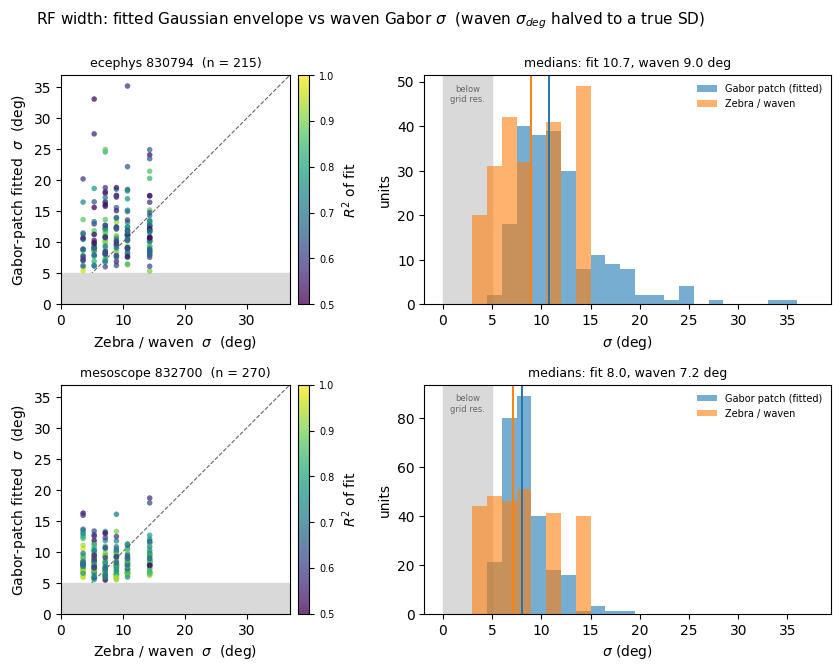

In [119]:
def plot_sigma_comparison(fitted, stem='sigma_envelope_vs_waven'):
    have = [(l, f[(f['p_value'] <= f['p_value'].min() + 1e-12) & f['usable']]
                .dropna(subset=['sigma_fit', 'sigma_waven']))
            for l, f in fitted.items()]
    have = [(l, d) for l, d in have if len(d) >= 3]
    if not have:
        print('no usable fits to plot')
        return None

    n = len(have)
    fig, axs = plt.subplots(n, 2, figsize=(9.5, 3.4 * n), squeeze=False)
    # one shared limit across sessions so the panels are comparable, sized to
    # the data but never tighter than the grid's own 5-45 deg measurable range
    top = max(20.0, *(max(d['sigma_fit'].max(), d['sigma_waven'].max())
                      for _, d in have)) * 1.05
    lim = (0, top)
    for i, (label, d) in enumerate(have):
        ax = axs[i, 0]
        # colour by fit quality: a cloud of marginal fits and a cloud of good
        # ones look identical in black, and they should not be read the same way
        sc = ax.scatter(d['sigma_waven'], d['sigma_fit'], c=d['r2_fit'],
                        cmap='viridis', vmin=.5, vmax=1, s=16, alpha=.75,
                        edgecolor='none')
        ax.plot(lim, lim, color='.4', lw=.8, ls='--', zorder=0)
        ax.axhspan(0, 5, color='.85', zorder=0)   # below the grid's resolution
        ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
        ax.set_xlabel('Zebra / waven  $\\sigma$  (deg)')
        ax.set_ylabel('Gabor-patch fitted  $\\sigma$  (deg)')
        ax.set_title(f'{label}  (n = {len(d)})', fontsize=9)
        fig.colorbar(sc, ax=ax, fraction=.046, pad=.02,
                     label='$R^2$ of fit').ax.tick_params(labelsize=7)

        ax = axs[i, 1]
        bins = np.arange(0, lim[1] + 1.5, 1.5)
        ax.hist(d['sigma_fit'], bins=bins, alpha=.6, label='Gabor patch (fitted)')
        ax.hist(d['sigma_waven'], bins=bins, alpha=.6, label='Zebra / waven')
        ax.axvline(d['sigma_fit'].median(), color='C0', lw=1.4)
        ax.axvline(d['sigma_waven'].median(), color='C1', lw=1.4)
        ax.axvspan(0, 5, color='.85', zorder=0)
        ax.text(2.5, ax.get_ylim()[1] * .96, 'below\ngrid res.', fontsize=6,
                ha='center', va='top', color='.4')
        ax.set_xlabel('$\\sigma$ (deg)'); ax.set_ylabel('units')
        ax.legend(fontsize=7, frameon=False)
        ax.set_title('medians: '
                     f'fit {d["sigma_fit"].median():.1f}, '
                     f'waven {d["sigma_waven"].median():.1f} deg', fontsize=9)

    fig.suptitle('RF width: fitted Gaussian envelope vs waven Gabor $\\sigma$'
                 '  (waven $\\sigma_{deg}$ halved to a true SD)', fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.985))
    save_figure(fig, stem)
    return fig


fig_sigma = plot_sigma_comparison(fitted)
plt.show()

### The fits themselves

A median is only worth as much as the fits behind it, so here are the strongest
units with the fitted envelope drawn on top: contours at 1 and 2 sigma over the
z-score map they were fitted to.

  -> compare_zebra_gabors__sigma_fit_overlay__ecephys-830794.png


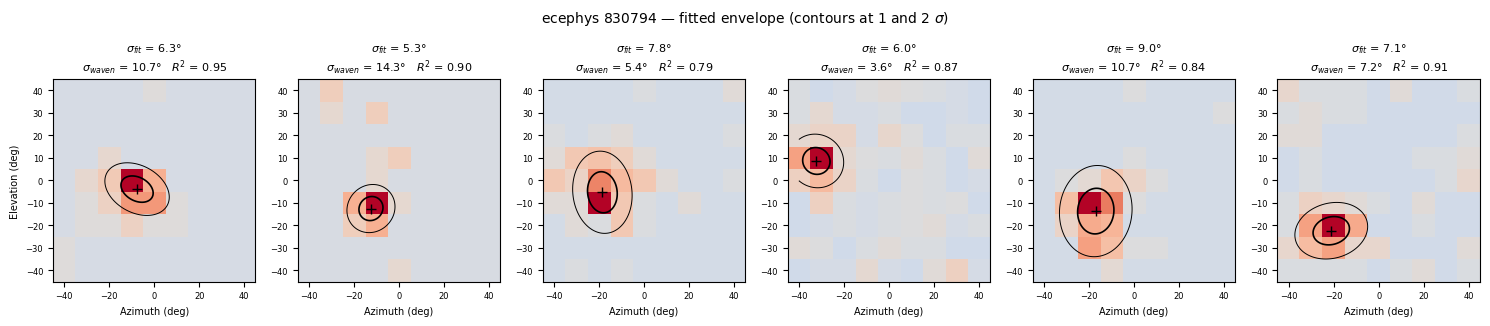

  -> compare_zebra_gabors__sigma_fit_overlay__mesoscope-832700.png


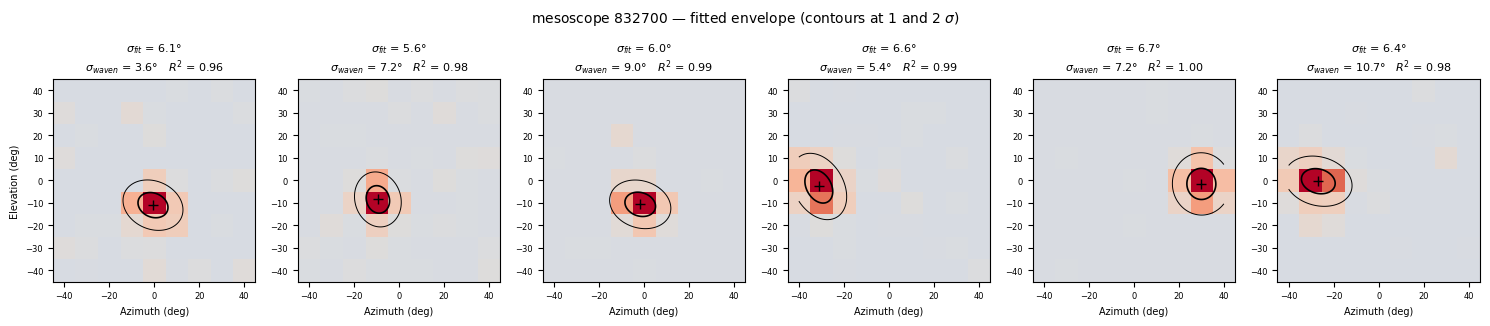

  -> compare_zebra_gabors__sigma_fit_overlay__slap2-829704-green.png


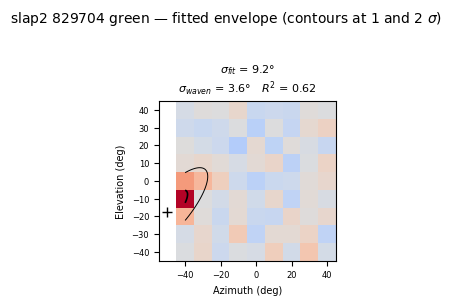

slap2 829704 red: no usable fits


In [120]:
def plot_fit_overlays(f, label, extent, n=6, stem=None):
    """The n most significant usable fits, envelope contours over the map.

    `extent` is passed in rather than read off the frame: pandas drops .attrs
    through the join inside fit_dataframe, so the fitted frame no longer knows
    which grid it came from.
    """
    sig = f['p_value'] <= f['p_value'].min() + 1e-12
    d = f[sig & f['usable']].sort_values('z_max', ascending=False).head(n)
    if not len(d):
        print(f'{label}: no usable fits')
        return None

    nx, ny = d['rf_map_gabor'].iloc[0].shape
    x = patch_centres(extent[:2], nx)
    y = patch_centres(extent[2:], ny)
    # a fine grid for smooth contours of the fitted model
    gx = np.linspace(x.min(), x.max(), 200)
    gy = np.linspace(y.min(), y.max(), 200)
    GX, GY = np.meshgrid(gx, gy, indexing='ij')

    fig, axs = plt.subplots(1, len(d), figsize=(2.5 * len(d), 3.0), squeeze=False)
    for ax, (_, r) in zip(axs[0], d.iterrows()):
        m = r['rf_map_gabor']
        v = np.nanmax(np.abs(m))
        ax.imshow(m.T, cmap='coolwarm', vmin=-v, vmax=v, origin='lower',
                  extent=extent, aspect='equal', interpolation='nearest')
        model = gaussian2d((GX.ravel(), GY.ravel()), r['amp_fit'], r['x0_fit'],
                           r['y0_fit'], r['sigma_x_fit'], r['sigma_y_fit'],
                           r['theta_fit'], 0.0).reshape(GX.shape)
        # 1 and 2 sigma of the fitted envelope, as fractions of its own peak
        ax.contour(GX, GY, model / r['amp_fit'], levels=[np.exp(-2), np.exp(-.5)],
                   colors='k', linewidths=[.7, 1.2])
        ax.plot(r['x0_fit'], r['y0_fit'], 'k+', ms=7)
        ax.set_title(f'$\\sigma_{{fit}}$ = {r["sigma_fit"]:.1f}$\\degree$\n'
                     f'$\\sigma_{{waven}}$ = {r["sigma_waven"]:.1f}$\\degree$   '
                     f'$R^2$ = {r["r2_fit"]:.2f}', fontsize=8)
        ax.tick_params(labelsize=6)
        ax.set_xlabel('Azimuth (deg)', fontsize=7)
    axs[0, 0].set_ylabel('Elevation (deg)', fontsize=7)
    fig.suptitle(f'{label} — fitted envelope (contours at 1 and 2 $\\sigma$)',
                 fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    if stem:
        save_figure(fig, stem)
    return fig


for label, f in fitted.items():
    fig = plot_fit_overlays(f, label, paired[label].attrs['extent'],
                            stem=f'sigma_fit_overlay__{slug(label)}')
    if fig is not None:
        plt.show()

## Size as area

Receptive fields are usually quoted as an area, not a width, and area is the
more honest scale for a *difference* in size: the 1-sigma ellipse

$$A = \pi\,\sigma_x\,\sigma_y$$

grows as the square of sigma, so the modest-sounding ~20% gap in sigma from the
previous section is a ~45% gap in area. For the Zebra side waven's filters are
circular by construction (`sigma_x == sigma_y`), so $A = \pi\sigma^2$.

`sigma_fit` was defined as $\sqrt{\sigma_x\sigma_y}$ precisely so that
$\pi\,\sigma_{fit}^2$ *is* the fitted ellipse's area — the equivalent circular
sigma preserves it exactly.

**Area is a monotone transform of sigma, so it cannot change a rank
correlation.** `spearmanr(area_fit, area_waven)` is identical, digit for digit,
to the sigma correlation reported above. What the area framing changes is the
magnitude of the discrepancy and the unit it is stated in; it is not
independent evidence that the two pipelines do or do not agree per unit. The
ratio distribution below is the part worth reading — it shows the *spread* of
per-unit disagreement, which a pair of medians hides.

In [121]:
area_rows = []
for label, f in fitted.items():
    sig = f['p_value'] <= f['p_value'].min() + 1e-12
    d = f[sig & f['usable']].dropna(subset=['area_fit', 'area_waven'])
    if len(d) < 3:
        area_rows.append({'session': label, 'n': len(d)})
        continue

    def q(s, p=0):
        return f'{s.median():.{p}f} [{s.quantile(.25):.{p}f}-{s.quantile(.75):.{p}f}]'

    ratio = d['area_ratio']
    area_rows.append({
        'session': label, 'n': len(d),
        'A_gabor (deg^2)': q(d['area_fit']),
        'A_gabor patch-deconv': q(d['area_rf']),
        'A_zebra (deg^2)': q(d['area_waven']),
        'A ratio': q(ratio, 2),
        'equiv. diameter gabor': f'{2 * d["sigma_fit"].median():.1f}',
        'equiv. diameter zebra': f'{2 * d["sigma_waven"].median():.1f}',
        # the fraction of units where the two disagree by more than 2x in area
        # either way — the spread the medians hide
        'within 2x': f'{100 * ratio.between(0.5, 2).mean():.0f}%',
    })
pd.DataFrame(area_rows).set_index('session')

,n,A_gabor (deg^2),A_gabor patch-deconv,A_zebra (deg^2),A ratio,equiv. diameter gabor,equiv. diameter zebra,within 2x
session,,,,,,,,
ecephys 830794,215,362 [245-533],327 [210-498],252 [161-363],1.66 [0.79-3.01],21.5,17.9,47%
mesoscope 832700,270,201 [145-274],167 [110-239],161 [91-363],1.04 [0.54-2.68],16.0,14.3,47%
slap2 829704 green,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slap2 829704 red,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Figure

Left: the two area distributions on a log axis, because areas are strongly
right-skewed and a linear axis buries the small ones. Right: the per-unit area
ratio as $\log_2$, so that 0 is agreement, +1 is the Gabor-patch fit twice the
Zebra area, and −1 is half. A distribution centred near 0 but broad is the
signature of the two sections combined — the populations match, the units do
not.

  -> compare_zebra_gabors__area_envelope_vs_waven.png


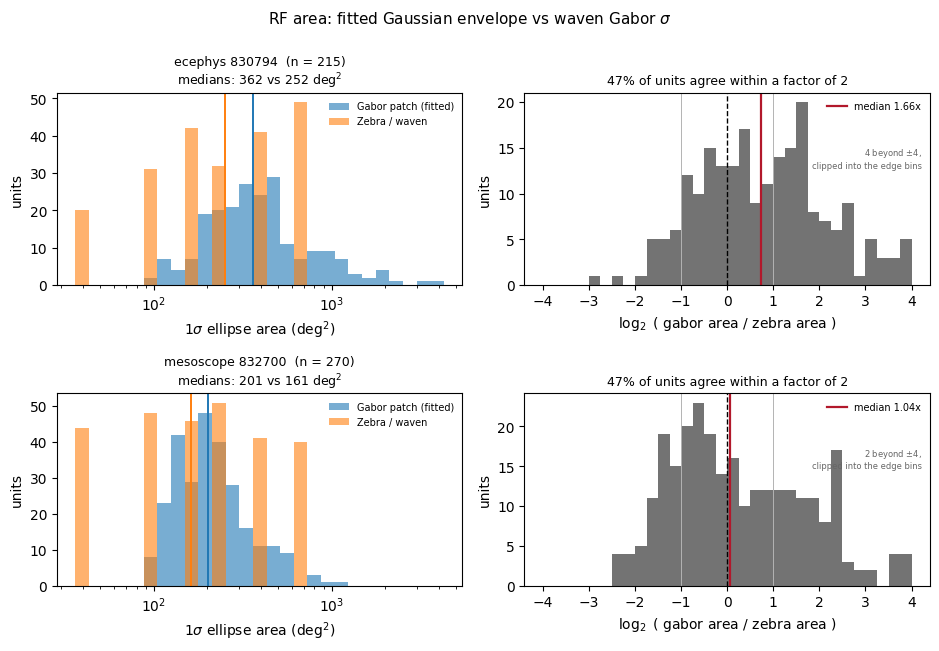

In [122]:
def plot_area_comparison(fitted, stem='area_envelope_vs_waven'):
    have = [(l, f[(f['p_value'] <= f['p_value'].min() + 1e-12) & f['usable']]
                .dropna(subset=['area_fit', 'area_waven']))
            for l, f in fitted.items()]
    have = [(l, d) for l, d in have if len(d) >= 3]
    if not have:
        print('no usable fits to plot')
        return None

    n = len(have)
    fig, axs = plt.subplots(n, 2, figsize=(9.5, 3.3 * n), squeeze=False)
    lo = min(min(d['area_fit'].min(), d['area_waven'].min()) for _, d in have)
    hi = max(max(d['area_fit'].max(), d['area_waven'].max()) for _, d in have)
    bins = np.logspace(np.log10(lo * .9), np.log10(hi * 1.1), 28)

    for i, (label, d) in enumerate(have):
        ax = axs[i, 0]
        ax.hist(d['area_fit'], bins=bins, alpha=.6, label='Gabor patch (fitted)')
        ax.hist(d['area_waven'], bins=bins, alpha=.6, label='Zebra / waven')
        ax.axvline(d['area_fit'].median(), color='C0', lw=1.4)
        ax.axvline(d['area_waven'].median(), color='C1', lw=1.4)
        ax.set_xscale('log')
        ax.set_xlabel('1$\\sigma$ ellipse area (deg$^2$)')
        ax.set_ylabel('units')
        ax.legend(fontsize=7, frameon=False)
        ax.set_title(f'{label}  (n = {len(d)})\nmedians: '
                     f'{d["area_fit"].median():.0f} vs '
                     f'{d["area_waven"].median():.0f} deg$^2$', fontsize=9)

        ax = axs[i, 1]
        lr = np.log2(d['area_ratio'].replace([np.inf, -np.inf], np.nan).dropna())
        # clip rather than let np.histogram drop them: a handful of units
        # disagree by more than 16x and they belong in the picture, piled into
        # the edge bin, not quietly missing from a plot about spread
        n_out = int((lr.abs() > 4).sum())
        ax.hist(lr.clip(-4, 4), bins=np.arange(-4, 4.25, .25), color='.45')
        if n_out:
            ax.text(.98, .72, f'{n_out} beyond $\\pm$4,\nclipped into the edge bins',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=6, color='.4')
        ax.axvline(0, color='k', lw=1, ls='--')          # exact agreement
        ax.axvline(lr.median(), color='#b2182b', lw=1.6,
                   label=f'median {2 ** lr.median():.2f}x')
        # +-1 is a factor of two either way
        for v in (-1, 1):
            ax.axvline(v, color='.7', lw=.7)
        ax.set_xlabel('$\\log_2$ ( gabor area / zebra area )')
        ax.set_ylabel('units')
        ax.legend(fontsize=7, frameon=False)
        ax.set_title(f'{100 * d["area_ratio"].between(0.5, 2).mean():.0f}% of units '
                     'agree within a factor of 2', fontsize=9)

    fig.suptitle('RF area: fitted Gaussian envelope vs waven Gabor $\\sigma$',
                 fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.985))
    save_figure(fig, stem)
    return fig


fig_area = plot_area_comparison(fitted)
plt.show()

## Zebra dff vs events — same pipeline, two input signals

Everything above runs the Zebra/waven pipeline on the raw ΔF/F trace. For the
mesoscope session (`sub-832700...`) it has also been run on OASIS-deconvolved
event rates, under `optimized/events/{session}` instead of the flat
`optimized/{session}` directory used everywhere above (that flat directory
*is* the dff run — same files, just not sorted into a `dff/` subfolder).
Only this session has both runs, so the comparison below is scoped to it.

Deconvolving to events strips the calcium indicator's slow decay. A real
receptive field should keep the same spatial structure but line up on a
shorter, sharper delay; an apparent RF that is really just dff's slow trend
should weaken once that decay is removed.


In [123]:
EVENTS_SESSION = 'sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys'
DFF_BASE = RF_ROOT / 'waven' / 'zebra' / 'optimized'
EVENTS_BASE = RF_ROOT / 'waven' / 'zebra' / 'optimized' / 'events'
DFF_EVENTS_PREFIX = 'compare_dff_events'


def save_dff_events_figure(fig, stem):
    """Write one figure for this section, kept apart from FILE_PREFIX's files."""
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    path = PLOT_DIR / f'{DFF_EVENTS_PREFIX}__{stem}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'  -> {path.name}')
    return path


def load_signal(base, session):
    """Every group's waven result under `base/session`, with a `group` column."""
    frames = []
    for group, path in sorted(discover_waven(session, base=base).items()):
        w = load_waven(path)
        if len(w):
            w.insert(0, 'group', group)
            frames.append(w)
    return (pd.concat(frames, ignore_index=True) if frames
            else pd.DataFrame(columns=['group'] + WAVEN_COLS))


dff_df = load_signal(DFF_BASE, EVENTS_SESSION)
events_df = load_signal(EVENTS_BASE, EVENTS_SESSION)

# inner join: unit_id is only unique within a group (bare ROI index), so the
# group column has to be part of the join key, same reasoning as load_session
signal_df = dff_df.merge(events_df, on=['group', 'unit_id'], how='inner',
                          suffixes=('_dff', '_events'))
print(f'dff: {len(dff_df)} units, events: {len(events_df)} units, '
      f'{len(signal_df)} paired (same unit_id, same group)')
display(signal_df.groupby('group').size().rename('n paired').to_frame())

PLOT_DIR.mkdir(parents=True, exist_ok=True)
table_cols = ['group', 'unit_id', 'abs_max_value_dff', 'abs_max_value_events',
              'delay_dff', 'duration_dff', 'delay_events', 'duration_events']
table_path = PLOT_DIR / f'{DFF_EVENTS_PREFIX}__strength_table.csv'
signal_df[table_cols].to_csv(table_path, index=False)
print(f'  -> {table_path.name}  ({len(signal_df)} rows)')


dff: 2458 units, events: 2458 units, 2458 paired (same unit_id, same group)


,n paired
group,
VISl_4,349
VISl_5,385
VISl_6,126
VISl_7,314
VISp_0,413
VISp_1,514
VISp_2,65
VISp_3,292


  -> compare_dff_events__strength_table.csv  (2458 rows)


### Peak correlation: does deconvolving to events change who looks tuned?

`abs_max_value` is each unit's own peak |r| over the whole Gabor parameter
grid. Both runs use the same statistic on the same units, so the question
here is not whether the two agree on a common scale (as with the Gabor-patch
z-scores above) but whether the *same* units clear the bar under both
signals — a straight scatter against the identity line, not a rank
correlation, is the right read.


  -> compare_dff_events__strength.png


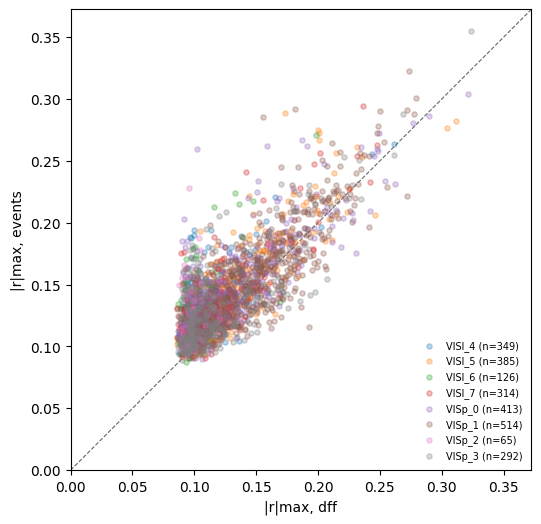

In [130]:
def plot_signal_strength(df, stem='strength'):
    d = df.dropna(subset=['abs_max_value_dff', 'abs_max_value_events'])
    groups = sorted(d['group'].unique())
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    top = max(d['abs_max_value_dff'].max(), d['abs_max_value_events'].max()) * 1.05
    for i, g in enumerate(groups):
        gd = d[d['group'] == g]
        ax.scatter(gd['abs_max_value_dff'], gd['abs_max_value_events'],
                   s=14, alpha=.3, color=f'C{i % 10}', label=f'{g} (n={len(gd)})')
    ax.plot([0, top], [0, top], color='.4', lw=.8, ls='--', zorder=0)
    ax.set_xlim(0, top); ax.set_ylim(0, top); ax.set_aspect('equal')
    ax.set_xlabel('|r|max, dff'); ax.set_ylabel('|r|max, events')
    rho = stats.spearmanr(d['abs_max_value_dff'], d['abs_max_value_events'])
    # ax.set_title('Zebra peak correlation, dff vs events\n'
    #               f'{EVENTS_SESSION}\n(n={len(d)}, Spearman '
    #               f'$\\rho$={rho.statistic:+.2f})', fontsize=9)
    ax.legend(fontsize=7, frameon=False, loc='lower right')
    fig.tight_layout()
    save_dff_events_figure(fig, stem)
    return fig


fig_strength = plot_signal_strength(signal_df)
plt.show()


### RF maps: same spatial structure, different delay?

Top units by dff `|r|max`, dff map next to its events counterpart. Both are
Pearson r on the same analysis grid, so — unlike the Zebra-vs-Gabor-patch
panels above, which compare correlation to a z-score — the two maps here
share one colour scale per row.


  -> compare_dff_events__maps.png


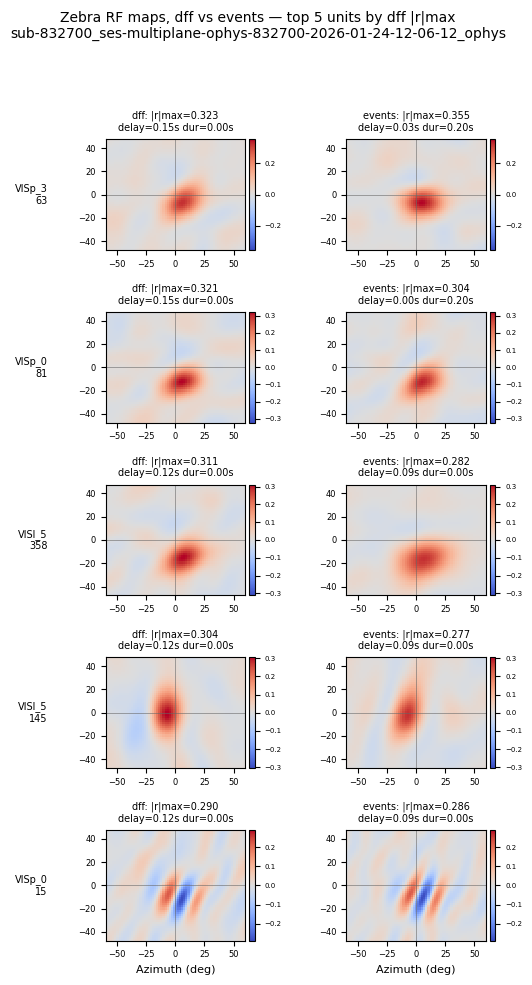

In [128]:
def plot_signal_map_pairs(df, n=5, stem='maps'):
    top = df.dropna(subset=['abs_max_value_dff']).nlargest(n, 'abs_max_value_dff')
    if not len(top):
        print('no paired units to plot')
        return None

    fig, axs = plt.subplots(len(top), 2, figsize=(5.6, 2.0 * len(top)), squeeze=False)
    for i, (_, row) in enumerate(top.iterrows()):
        m_dff, m_ev = row['rf_map_dff'], row['rf_map_events']
        vmax = max(np.nanmax(np.abs(m_dff)), np.nanmax(np.abs(m_ev)))
        vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0
        for j, (m, tag, delay, dur) in enumerate([
                (m_dff, 'dff', row['delay_dff'], row['duration_dff']),
                (m_ev, 'events', row['delay_events'], row['duration_events'])]):
            ax = axs[i, j]
            im = ax.imshow(m.T, cmap='coolwarm', vmin=-vmax, vmax=vmax,
                            extent=WAVEN_EXTENT, origin='upper', aspect='equal',
                            interpolation='nearest')
            ax.axhline(0, color='.4', lw=.4); ax.axvline(0, color='.4', lw=.4)
            ax.tick_params(labelsize=6)
            ax.set_title(f'{tag}: |r|max={np.nanmax(np.abs(m)):.3f}\n'
                         f'delay={delay:.2f}s dur={dur:.2f}s', fontsize=7)
            fig.colorbar(im, ax=ax, fraction=.046, pad=.02).ax.tick_params(labelsize=5)
        axs[i, 0].set_ylabel(f'{row["group"]}\n{row["unit_id"]}', fontsize=7,
                             rotation=0, ha='right', va='center', labelpad=22)
    for ax in axs[-1]:
        ax.set_xlabel('Azimuth (deg)', fontsize=8)
    fig.suptitle(f'Zebra RF maps, dff vs events — top {len(top)} units by dff |r|max\n'
                 f'{EVENTS_SESSION}', fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.6 / (2.0 * len(top))))
    save_dff_events_figure(fig, stem)
    return fig


fig_maps = plot_signal_map_pairs(signal_df)
plt.show()


### Delay tuning: does events sharpen the peak?

The delay curve is each unit's `abs_max_value` swept over `delay` at its own
best `duration` (same "fix duration at its optimum" convention as
`analysis/plotting.py`'s `plot_optimized_results`) — dff and events can pick
different best durations, so each curve uses its own. This is the direct test
of the prediction above: if an apparent RF is really dff's slow calcium decay,
deconvolving to events should sharpen the peak and pull it to a shorter delay;
a real RF should keep roughly the same peak delay under both signals.

In [126]:
def discover_all_values(session, base=None):
    """{group_key: path} for one session's waven delay x duration sweep CSVs."""
    out = {}
    d = (base if base is not None else RF_ROOT / 'waven' / 'zebra' / 'optimized') / session
    if not d.is_dir():
        return out
    for f in sorted(d.glob(f'optimized__{session}__*_all_values.csv')):
        tail = f.stem[len(f'optimized__{session}__'):]
        if not tail.endswith('_all_values'):
            continue
        tail = tail[:-len('_all_values')]
        m = re.match(r'^(?P<group>.+?)(?:__trial_(?P<trial>\d+))?__phase_(?P<phase>\d+)$', tail)
        if not m:
            continue
        if int(m.group('phase')) != PHASE:
            continue
        if m.group('trial') is not None and int(m.group('trial')) != TRIAL:
            continue
        out[m.group('group')] = f
    return out


def load_all_values(base, session):
    """Every group's full delay x duration sweep under `base/session`.

    One row per (group, unit_id, delay, duration) - the raw table a per-unit
    delay curve is sliced out of, unlike load_signal()'s single best
    (delay, duration) per unit.
    """
    frames = []
    for group, path in sorted(discover_all_values(session, base=base).items()):
        d = pd.read_csv(path)
        d['unit_id'] = d['unit_id'].map(canonical_unit_id)
        d.insert(0, 'group', group)
        frames.append(d)
    return (pd.concat(frames, ignore_index=True) if frames
            else pd.DataFrame(columns=['group', 'unit_id', 'delay', 'duration', 'abs_max_value']))


dff_sweep = load_all_values(DFF_BASE, EVENTS_SESSION)
events_sweep = load_all_values(EVENTS_BASE, EVENTS_SESSION)
print(f'dff_sweep: {len(dff_sweep)} rows, events_sweep: {len(events_sweep)} rows, '
      f'delays={sorted(dff_sweep["delay"].unique())}')

dff_sweep: 44244 rows, events_sweep: 44244 rows, delays=[np.float64(0.0), np.float64(0.03), np.float64(0.06), np.float64(0.09), np.float64(0.12), np.float64(0.15)]


  -> compare_dff_events__delay_curves.png


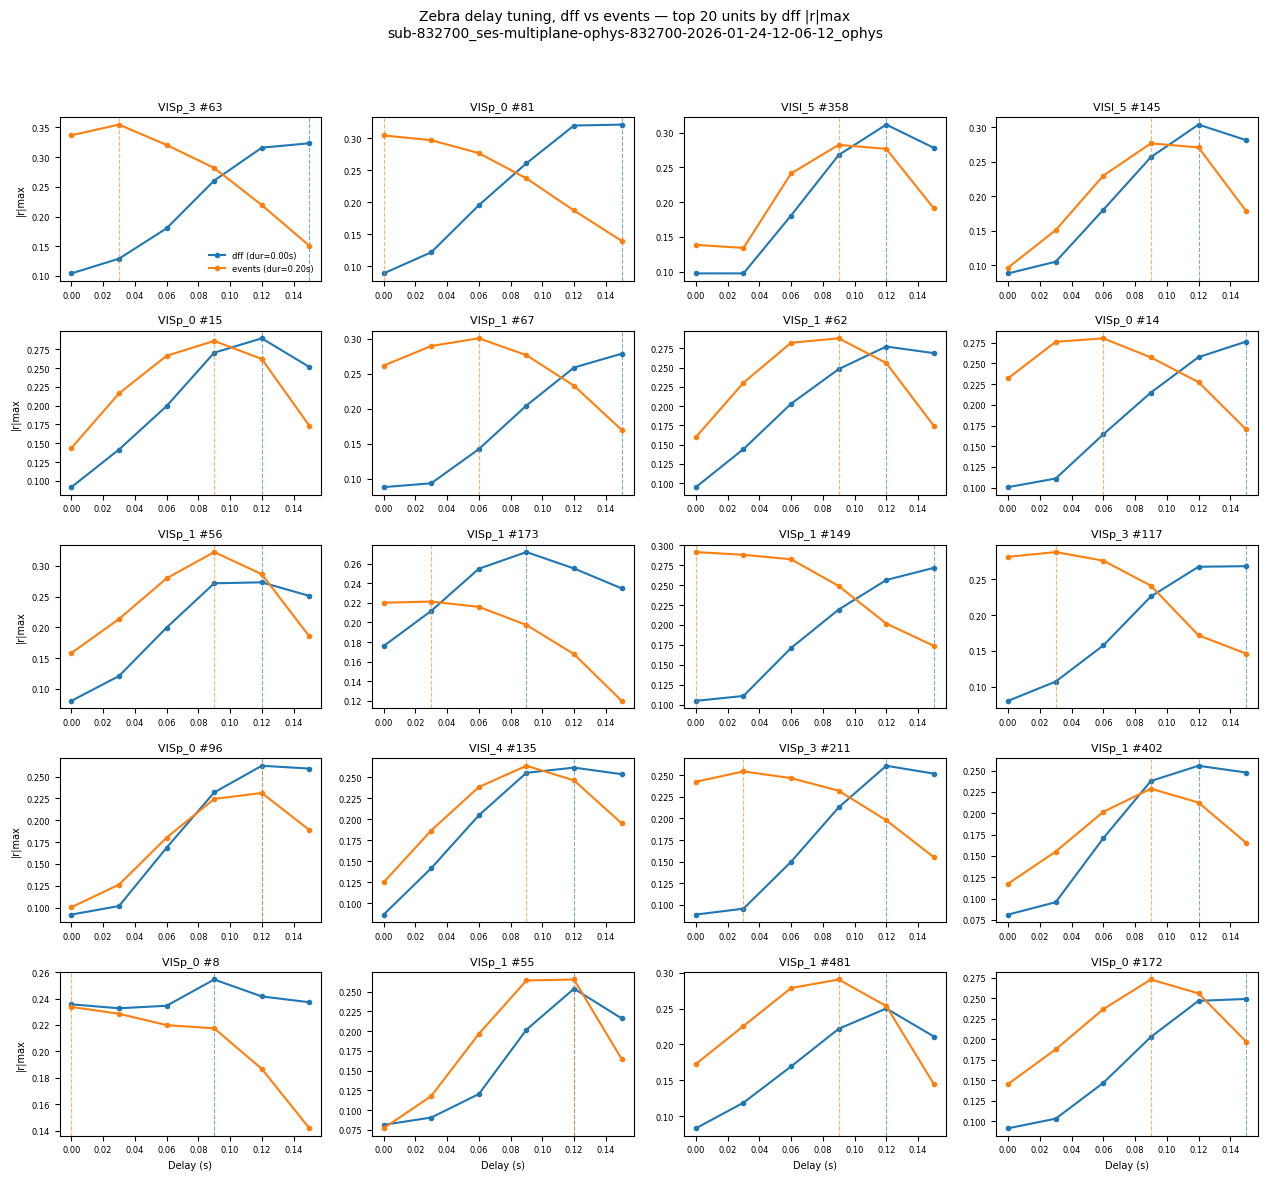

In [127]:
def plot_delay_curves(df, dff_sweep, events_sweep, n=20, stem='delay_curves'):
    """Delay tuning of the top n units by dff |r|max, dff vs events overlaid.

    Each unit's curve is sliced from its own sweep table at *its own* best
    duration under that signal (duration_dff / duration_events can differ,
    since deconvolving to events can shift which window integrates best).
    """
    top = df.dropna(subset=['abs_max_value_dff']).nlargest(n, 'abs_max_value_dff')
    if not len(top):
        print('no paired units to plot')
        return None

    ncols = 4
    nrows = int(np.ceil(len(top) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows), squeeze=False)

    for i, (_, row) in enumerate(top.iterrows()):
        ax = axs[i // ncols, i % ncols]
        for sweep, dur_col, delay_col, color, tag in [
                (dff_sweep, 'duration_dff', 'delay_dff', 'C0', 'dff'),
                (events_sweep, 'duration_events', 'delay_events', 'C1', 'events')]:
            dur = row[dur_col]
            c = sweep[(sweep['group'] == row['group']) & (sweep['unit_id'] == row['unit_id'])
                      & np.isclose(sweep['duration'], dur)].sort_values('delay')
            if not len(c):
                continue
            ax.plot(c['delay'], c['abs_max_value'], marker='o', markersize=3,
                    color=color, label=f'{tag} (dur={dur:.2f}s)')
            ax.axvline(row[delay_col], color=color, lw=.8, ls='--', alpha=.6)
        ax.set_title(f'{row["group"]} #{row["unit_id"]}', fontsize=8)
        ax.tick_params(labelsize=6)
        if i == 0:
            ax.legend(fontsize=6, frameon=False)

    for ax in axs[-1]:
        ax.set_xlabel('Delay (s)', fontsize=7)
    for ax in axs[:, 0]:
        ax.set_ylabel('|r|max', fontsize=7)
    for i in range(len(top), nrows * ncols):
        axs[i // ncols, i % ncols].set_axis_off()

    fig.suptitle(f'Zebra delay tuning, dff vs events — top {len(top)} units by dff |r|max\n'
                 f'{EVENTS_SESSION}', fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.55 / (2.4 * nrows)))
    save_dff_events_figure(fig, stem)
    return fig


fig_delay = plot_delay_curves(signal_df, dff_sweep, events_sweep, n=20)
plt.show()